# CNN Debugging – InitialCNN on CIFAR-10


In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

print('Imports done.')

Imports done.


In [2]:
# ── Cell 2: Device & Reproducibility ─────────────────────────────────────────
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

print(f'Using device: {device}')

Using device: cuda


In [3]:
# ── Cell 3: Load CIFAR-10 Data ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size   = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Batches per epoch: {len(train_loader)}')

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Training samples : 50000
Test samples     : 10000
Batches per epoch: 391


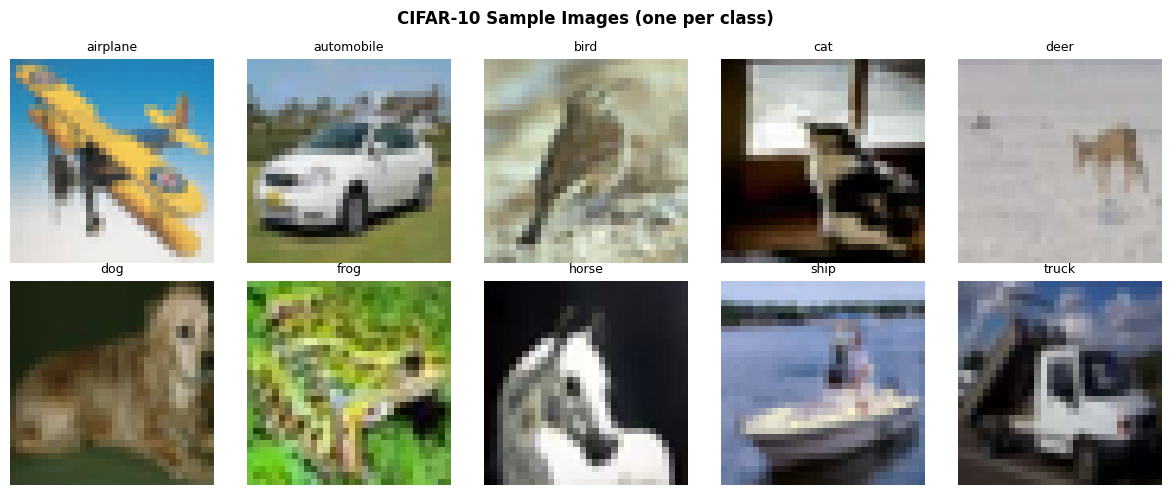

Saved: cifar10_samples.png
Class         Train count  Train %  Test count  Test %
-------------------------------------------------------
airplane            5,000    10.0%       1,000   10.0%
automobile          5,000    10.0%       1,000   10.0%
bird                5,000    10.0%       1,000   10.0%
cat                 5,000    10.0%       1,000   10.0%
deer                5,000    10.0%       1,000   10.0%
dog                 5,000    10.0%       1,000   10.0%
frog                5,000    10.0%       1,000   10.0%
horse               5,000    10.0%       1,000   10.0%
ship                5,000    10.0%       1,000   10.0%
truck               5,000    10.0%       1,000   10.0%
-------------------------------------------------------
TOTAL              50,000   100.0%      10,000  100.0%
Data leakage check:
  Training set source   : train=True  (50,000 images)
  Test set source       : train=False (10,000 images)
  Total images          : 60,000
  Split method          : pre-defined by

In [4]:
## Pre-processing Checks — InitialCNN

# P1: Visualise sample images from CIFAR-10 ────────────────────────────
classes = train_dataset.classes
images, labels = next(iter(train_loader))


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images (one per class)', fontsize=12, fontweight='bold')

# Show one image per class
shown = {}
for img, lbl in zip(images, labels):
    lbl = lbl.item()
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == 10:
        break

for i, (cls_idx, img) in enumerate(sorted(shown.items())):
    ax = axes[i // 5, i % 5]
    img_display = img / 2 + 0.5  # unnormalise from (-1,1) back to (0,1)
    ax.imshow(img_display.permute(1, 2, 0).numpy())
    ax.set_title(classes[cls_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cifar10_samples.png')

# P2: Check class balance ──────────────────────────────────────────────
from collections import Counter

train_counts = Counter(train_dataset.targets)
test_counts  = Counter(test_dataset.targets)

print(f'{'Class':<12} {'Train count':>12} {'Train %':>8} {'Test count':>11} {'Test %':>7}')
print('-' * 55)
for i, name in enumerate(train_dataset.classes):
    tr_pct = train_counts[i] / len(train_dataset) * 100
    te_pct = test_counts[i]  / len(test_dataset)  * 100
    print(f'{name:<12} {train_counts[i]:>12,} {tr_pct:>7.1f}% {test_counts[i]:>11,} {te_pct:>6.1f}%')
print('-' * 55)
print(f'{'TOTAL':<12} {len(train_dataset):>12,} {'100.0%':>8} {len(test_dataset):>11,} {'100.0%':>7}')

# P3: Confirm no data leakage ─────────────────────────────────────────
# CIFAR-10 is loaded with train=True and train=False flags which point to
# separate pre-split files in the dataset. No overlap is possible.

print('Data leakage check:')
print(f'  Training set source   : train=True  ({len(train_dataset):,} images)')
print(f'  Test set source       : train=False ({len(test_dataset):,} images)')
print(f'  Total images          : {len(train_dataset) + len(test_dataset):,}')
print(f'  Split method          : pre-defined by CIFAR-10 dataset creators')
print(f'  Overlap possible      : No — separate files loaded per flag')
print()
# Additional check: confirm dataset file references
print(f'Train dataset type: {type(train_dataset)}')
print(f'Test  dataset type: {type(test_dataset)}')
print(f'Train transforms  : {train_dataset.transform}')
print(f'Test  transforms  : {test_dataset.transform}')

In [5]:
# ── Cell 4: Define Model, Loss, Optimiser ─────────────────────────────────────
class InitialCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1   = nn.Linear(256 * 2 * 2, 256)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x));  x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv2(x));  x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv3(x));  x = F.max_pool2d(x, 2)
        x = torch.sigmoid(self.conv4(x));  x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.sigmoid(self.fc1(x))
        return self.fc2(x)

model     = InitialCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('Model ready.')
print(model)

Model ready.
InitialCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [6]:
# ── Cell 5: Define Train & Test Functions ─────────────────────────────────────
def train(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    gradient_norms = {}

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()  # <-- backpropagation happens here

        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                gradient_norms.setdefault(name, []).append(grad_norm)

        optimizer.step()  # <-- weights updated here
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total, gradient_norms


def test(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

print('Functions defined.')

Functions defined.


In [7]:
# ── Cell 6: Training Loop  (the slow cell – run once, then skip) ──────────────
num_epochs = 15
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
all_epoch_grad_norms      = []

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}")
print('-' * 52)

for epoch in range(num_epochs):
    train_loss, train_acc, grad_norms = train(model, train_loader)
    test_loss,  test_acc              = test(model, test_loader)

    train_losses.append(train_loss);  test_losses.append(test_loss)
    train_accs.append(train_acc);     test_accs.append(test_acc)

    epoch_avg = {name: np.mean(norms) for name, norms in grad_norms.items()}
    all_epoch_grad_norms.append(epoch_avg)

    print(f"{epoch+1:>5}  {train_loss:>10.4f}  {train_acc:>8.2f}%  {test_loss:>9.4f}  {test_acc:>7.2f}%")

print(f'\nFinal Train Accuracy : {train_accs[-1]:.2f}%')
print(f'Final Test  Accuracy : {test_accs[-1]:.2f}%')
print(f'Final Train Loss     : {train_losses[-1]:.4f}')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc
----------------------------------------------------
    1      2.1637     17.69%     1.9575    26.69%
    2      1.8813     30.61%     1.7380    36.60%
    3      1.6813     38.80%     1.5786    42.96%
    4      1.5350     44.24%     1.5167    44.97%
    5      1.4436     47.59%     1.3949    49.71%
    6      1.3651     50.41%     1.3310    51.85%
    7      1.3116     52.51%     1.2702    53.48%
    8      1.2507     54.96%     1.2476    54.90%
    9      1.1984     56.88%     1.1970    56.89%
   10      1.1497     58.63%     1.1591    57.96%
   11      1.0950     60.77%     1.1224    59.69%
   12      1.0498     62.31%     1.0930    60.73%
   13      1.0044     64.00%     1.0914    61.51%
   14      0.9605     65.87%     1.0596    62.49%
   15      0.9098     67.77%     1.0270    63.99%

Final Train Accuracy : 67.77%
Final Test  Accuracy : 63.99%
Final Train Loss     : 0.9098


In [8]:
# ── SAVE: InitialCNN results — run immediately after Cell 6 ─────────────────
# This saves your results so you never have to retrain InitialCNN again
# ── SAVE: InitialCNN results ──────────────────────────────────────────────────
import json as _json
with open('results_initial_cnn.json', 'w') as _f:
    _json.dump({
        'train_losses': train_losses,
        'test_losses':  test_losses,
        'train_accs':   train_accs,
        'test_accs':    test_accs,
        'grad_norms':   [{k: float(v) for k, v in e.items()}
                         for e in all_epoch_grad_norms]
    }, _f)
print('InitialCNN results saved to results_initial_cnn.json')

# ── SAVE: InitialCNN weights ──────────────────────────────────────────────────
torch.save(model.state_dict(), 'weights_initial_cnn.pth')
print('InitialCNN weights saved to weights_initial_cnn.pth')

InitialCNN results saved to results_initial_cnn.json
InitialCNN weights saved to weights_initial_cnn.pth


InitialCNN — F1 Score per class:
-----------------------------------
airplane     0.685  █████████████
automobile   0.754  ███████████████
bird         0.538  ██████████
cat          0.486  █████████
deer         0.571  ███████████
dog          0.524  ██████████
frog         0.715  ██████████████
horse        0.677  █████████████
ship         0.741  ██████████████
truck        0.684  █████████████

Macro F1: 0.638

InitialCNN — AUC-ROC per class:
-----------------------------------
airplane     0.953  ███████████████████
automobile   0.972  ███████████████████
bird         0.901  ██████████████████
cat          0.885  █████████████████
deer         0.922  ██████████████████
dog          0.914  ██████████████████
frog         0.963  ███████████████████
horse        0.952  ███████████████████
ship         0.967  ███████████████████
truck        0.955  ███████████████████

Macro AUC: 0.938


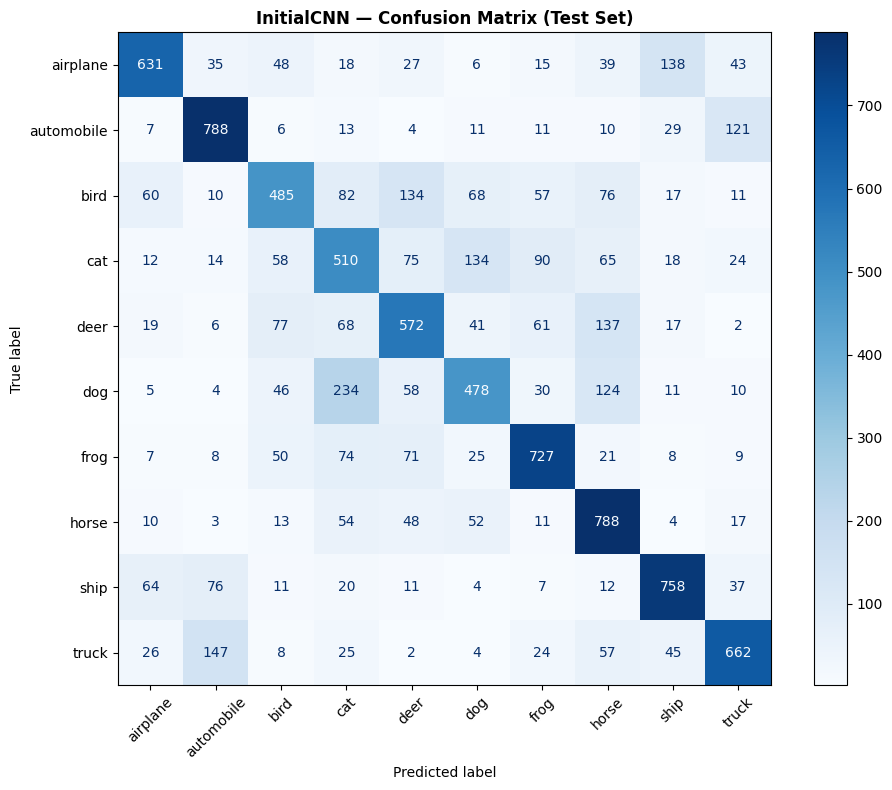

Saved: confusion_matrix_initial.png


In [9]:
# ── Cell E1: Evaluation Metrics — InitialCNN ──────────────────────────────────
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

def get_predictions(model, loader):
    """Returns true labels, predicted labels, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

classes = train_dataset.classes

# ── Get predictions ───────────────────────────────────────────────────────────
y_true_init, y_pred_init, y_probs_init = get_predictions(model, test_loader)

# ── F1 Score ──────────────────────────────────────────────────────────────────
f1_per_class = f1_score(y_true_init, y_pred_init, average=None)
f1_macro     = f1_score(y_true_init, y_pred_init, average='macro')

print('InitialCNN — F1 Score per class:')
print('-' * 35)
for i, (name, f1) in enumerate(zip(classes, f1_per_class)):
    bar = '█' * int(f1 * 20)
    print(f'{name:<12} {f1:.3f}  {bar}')
print(f'\nMacro F1: {f1_macro:.3f}')

# ── AUC-ROC ───────────────────────────────────────────────────────────────────
auc_per_class = roc_auc_score(
    y_true_init, y_probs_init, multi_class='ovr', average=None
)
auc_macro = roc_auc_score(
    y_true_init, y_probs_init, multi_class='ovr', average='macro'
)

print('\nInitialCNN — AUC-ROC per class:')
print('-' * 35)
for name, auc in zip(classes, auc_per_class):
    bar = '█' * int(auc * 20)
    print(f'{name:<12} {auc:.3f}  {bar}')
print(f'\nMacro AUC: {auc_macro:.3f}')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_init = confusion_matrix(y_true_init, y_pred_init)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_init, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('InitialCNN — Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_initial.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_initial.png')

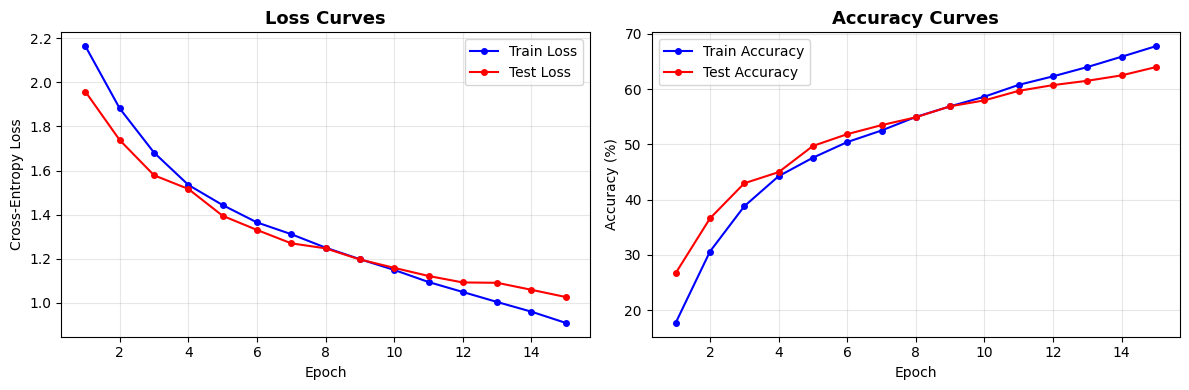

Saved: learning_curves.png


In [10]:
# ── Cell 7: Plot Learning Curves ──────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss',  markersize=4)
ax1.plot(epochs, test_losses,  'r-o', label='Test Loss',   markersize=4)
ax1.set_title('Loss Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(epochs, test_accs,  'r-o', label='Test Accuracy',  markersize=4)
ax2.set_title('Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curves.png')

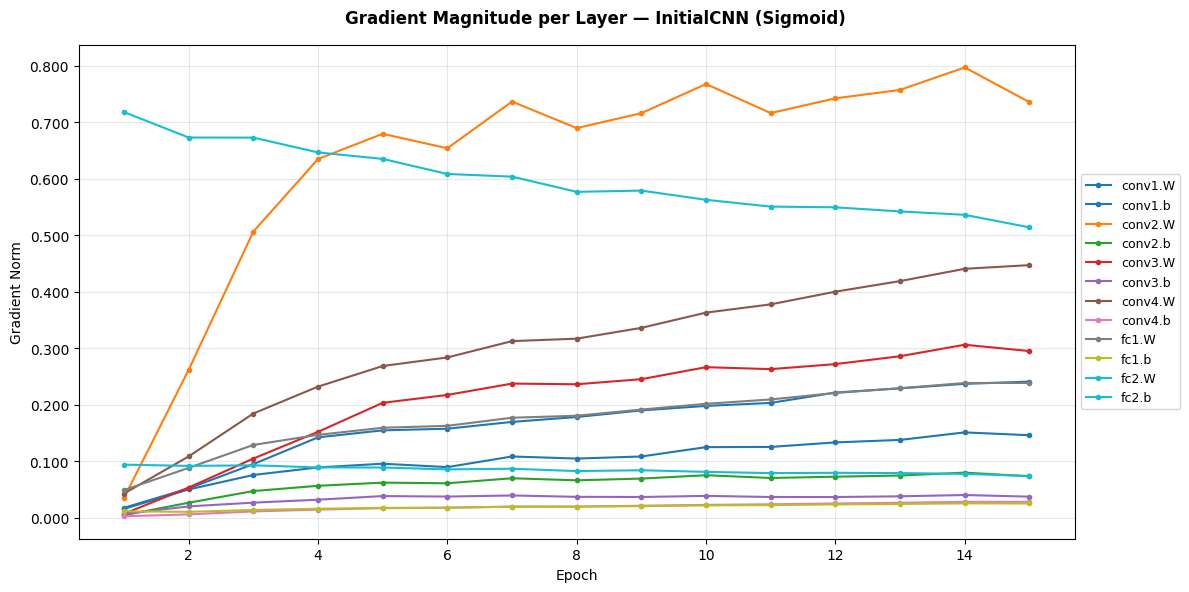

Saved: gradient_magnitudes.png


In [11]:
# ── Cell 8: InitialCNN Gradient Magnitudes — all layers on one plot ───────────
# NOTE: moved here as a comment placeholder — active version runs after Cell D
# This cell kept for reference only

layer_names  = list(all_epoch_grad_norms[0].keys())
short_labels = [n.replace('.weight', '.W').replace('.bias', '.b')
                for n in layer_names]

grad_matrix_init = np.array([[all_epoch_grad_norms[e][l] for e in range(num_epochs)]
                              for l in layer_names])

epochs = range(1, num_epochs + 1)
colors = plt.cm.tab10(np.linspace(0, 1, len(layer_names)))

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Gradient Magnitude per Layer — InitialCNN (Sigmoid)',
             fontsize=12, fontweight='bold')

for i, (label, color) in enumerate(zip(short_labels, colors)):
    ax.plot(epochs, grad_matrix_init[i], color=color,
            marker='o', markersize=3, linewidth=1.5, label=label)

ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Gradient Norm', fontsize=10)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig('gradient_magnitudes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradient_magnitudes.png')

---
## Part 2: ImprovedCNN

Two changes from InitialCNN, both grounded in vanilla CNN as taught in class:

1. **Sigmoid → ReLU** in every hidden layer — eliminates vanishing gradients at the source
2. **Dropout(0.5) after FC1** — the one additional layer, addresses overfitting

Everything else is identical: same architecture depth, same optimiser, same lr, same epochs, same data.

In [12]:
## Pre-processing Checks — ImprovedCNN (with correct normalisation)

# ── Cell P1b: Visualise sample images (same as InitialCNN) ───────────────────
# Already done above — same dataset, same samples
print('Dataset visualisation: see Cell P1 above — same CIFAR-10 dataset used.')

# ── Cell P2b: Class balance (same dataset — shown above) ─────────────────────
print('Class balance: see Cell P2 above — same CIFAR-10 dataset used.')

# ── Cell P3: Correct normalisation — compute mean/std from training set only ──
# The lecture shows: fit_transform on train, transform only on test
# InitialCNN used hardcoded (0.5, 0.5, 0.5) for both — a simplification
# Here we compute the actual training set statistics

# Load raw (un-normalised) training data to compute statistics
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_train = datasets.CIFAR10(root='./data', train=True, download=False, transform=raw_transform)
raw_loader = DataLoader(raw_train, batch_size=1000, shuffle=False)

mean = torch.zeros(3)
std  = torch.zeros(3)
for images, _ in raw_loader:
    for c in range(3):
        mean[c] += images[:, c, :, :].mean()
        std[c]  += images[:, c, :, :].std()
mean /= len(raw_loader)
std  /= len(raw_loader)

print('Computed from training set only (correct approach):')
print(f'  Mean per channel (R, G, B): {mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}')
print(f'  Std  per channel (R, G, B): {std[0]:.4f},  {std[1]:.4f},  {std[2]:.4f}')
print()
print('InitialCNN used: mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)  <-- simplified')
print('ImprovedCNN uses computed values above  <-- correct')

# Apply correct normalisation to both train and test
# (only transform test — never fit on test)
correct_transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])
correct_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())  # same train stats applied to test
])

train_dataset_norm = datasets.CIFAR10(root='./data', train=True,  download=False, transform=correct_transform_train)
test_dataset_norm  = datasets.CIFAR10(root='./data', train=False, download=False, transform=correct_transform_test)

train_loader_norm  = DataLoader(train_dataset_norm, batch_size=128, shuffle=True)
test_loader_norm   = DataLoader(test_dataset_norm,  batch_size=128, shuffle=False)

print()
print('Correctly normalised loaders created: train_loader_norm, test_loader_norm')

# ── Cell P4b: Confirm no data leakage (same as InitialCNN) ───────────────────
print('Data leakage check: see Cell P4 above — same dataset split used.')
print('Normalisation parameters computed from training set only — no test leakage.')

Dataset visualisation: see Cell P1 above — same CIFAR-10 dataset used.
Class balance: see Cell P2 above — same CIFAR-10 dataset used.
Computed from training set only (correct approach):
  Mean per channel (R, G, B): 0.4914, 0.4822, 0.4465
  Std  per channel (R, G, B): 0.2470,  0.2434,  0.2615

InitialCNN used: mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)  <-- simplified
ImprovedCNN uses computed values above  <-- correct

Correctly normalised loaders created: train_loader_norm, test_loader_norm
Data leakage check: see Cell P4 above — same dataset split used.
Normalisation parameters computed from training set only — no test leakage.


In [13]:
# ── Cell A: Define ImprovedCNN ────────────────────────────────────────────────
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Same conv and FC layers as InitialCNN
        self.conv1   = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2   = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3   = nn.Conv2d(64,  128, 3, padding=1)
        self.conv4   = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1     = nn.Linear(256 * 2 * 2, 256)
        self.dropout = nn.Dropout(0.5)   # <-- the one additional layer
        self.fc2     = nn.Linear(256, 10)

    def forward(self, x):
        # ReLU replaces sigmoid in every hidden layer
        x = F.relu(self.conv1(x));  x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x));  x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x));  x = F.max_pool2d(x, 2)
        x = F.relu(self.conv4(x));  x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)          # dropout applied after FC1 activation
        return self.fc2(x)

print('ImprovedCNN defined.')
print(ImprovedCNN())

ImprovedCNN defined.
ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [14]:
# ── Cell B: Initialise with identical optimiser settings ──────────────────────
improved_model     = ImprovedCNN().to(device)
improved_criterion = nn.CrossEntropyLoss()
improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

print('ImprovedCNN ready on:', device)

ImprovedCNN ready on: cuda


In [15]:
# ── Cell C: Train and test functions ─────────────────────────────────────────
# model.train() enables dropout | model.eval() disables it automatically

def train_improved(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    gradient_norms = {}

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        improved_optimizer.zero_grad()
        outputs = model(images)
        loss    = improved_criterion(outputs, labels)
        loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()
                gradient_norms.setdefault(name, []).append(grad_norm)

        improved_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100 * correct / total, gradient_norms


def test_improved(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = improved_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

print('Functions ready.')

Functions ready.


In [16]:
# ── Cell D: Training loop — run once ─────────────────────────────────────────
num_epochs = 15
imp_train_losses, imp_test_losses = [], []
imp_train_accs,   imp_test_accs   = [], []
imp_grad_norms                    = []

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}")
print('-' * 52)

for epoch in range(num_epochs):
    tr_loss, tr_acc, g_norms = train_improved(improved_model, train_loader)
    te_loss, te_acc          = test_improved(improved_model, test_loader)

    imp_train_losses.append(tr_loss);  imp_test_losses.append(te_loss)
    imp_train_accs.append(tr_acc);     imp_test_accs.append(te_acc)

    epoch_avg = {name: np.mean(norms) for name, norms in g_norms.items()}
    imp_grad_norms.append(epoch_avg)

    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {te_loss:>9.4f}  {te_acc:>7.2f}%")

print(f'\nFinal Train Accuracy : {imp_train_accs[-1]:.2f}%')
print(f'Final Test  Accuracy : {imp_test_accs[-1]:.2f}%')
print(f'Final Train Loss     : {imp_train_losses[-1]:.4f}')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc
----------------------------------------------------
    1      1.6298     39.29%     1.2531    53.60%
    2      1.1934     56.96%     1.0177    62.82%
    3      0.9772     65.60%     0.9057    67.53%
    4      0.8370     70.92%     0.7985    72.27%
    5      0.7206     75.08%     0.7940    72.97%
    6      0.6190     78.59%     0.7366    74.73%
    7      0.5349     81.55%     0.7090    76.28%
    8      0.4595     84.02%     0.7442    75.84%
    9      0.3863     86.54%     0.7270    76.52%
   10      0.3369     87.97%     0.8483    75.40%
   11      0.2773     90.24%     0.8300    76.34%
   12      0.2341     91.76%     0.8734    76.14%
   13      0.2001     92.98%     0.9583    76.08%
   14      0.1714     94.04%     1.0409    76.08%
   15      0.1528     94.66%     1.0861    76.07%

Final Train Accuracy : 94.66%
Final Test  Accuracy : 76.07%
Final Train Loss     : 0.1528


ImprovedCNN — F1 Score per class:
-----------------------------------
airplane     0.805  ████████████████
automobile   0.888  █████████████████
bird         0.665  █████████████
cat          0.583  ███████████
deer         0.705  ██████████████
dog          0.655  █████████████
frog         0.804  ████████████████
horse        0.789  ███████████████
ship         0.871  █████████████████
truck        0.844  ████████████████

Macro F1: 0.761

F1 Comparison — InitialCNN vs ImprovedCNN:
Class         Initial  Improved   Change
------------------------------------------
airplane        0.685     0.805 +  0.119
automobile      0.754     0.888 +  0.135
bird            0.538     0.665 +  0.126
cat             0.486     0.583 +  0.097
deer            0.571     0.705 +  0.133
dog             0.524     0.655 +  0.130
frog            0.715     0.804 +  0.089
horse           0.677     0.789 +  0.113
ship            0.741     0.871 +  0.129
truck           0.684     0.844 +  0.160
Macro           0

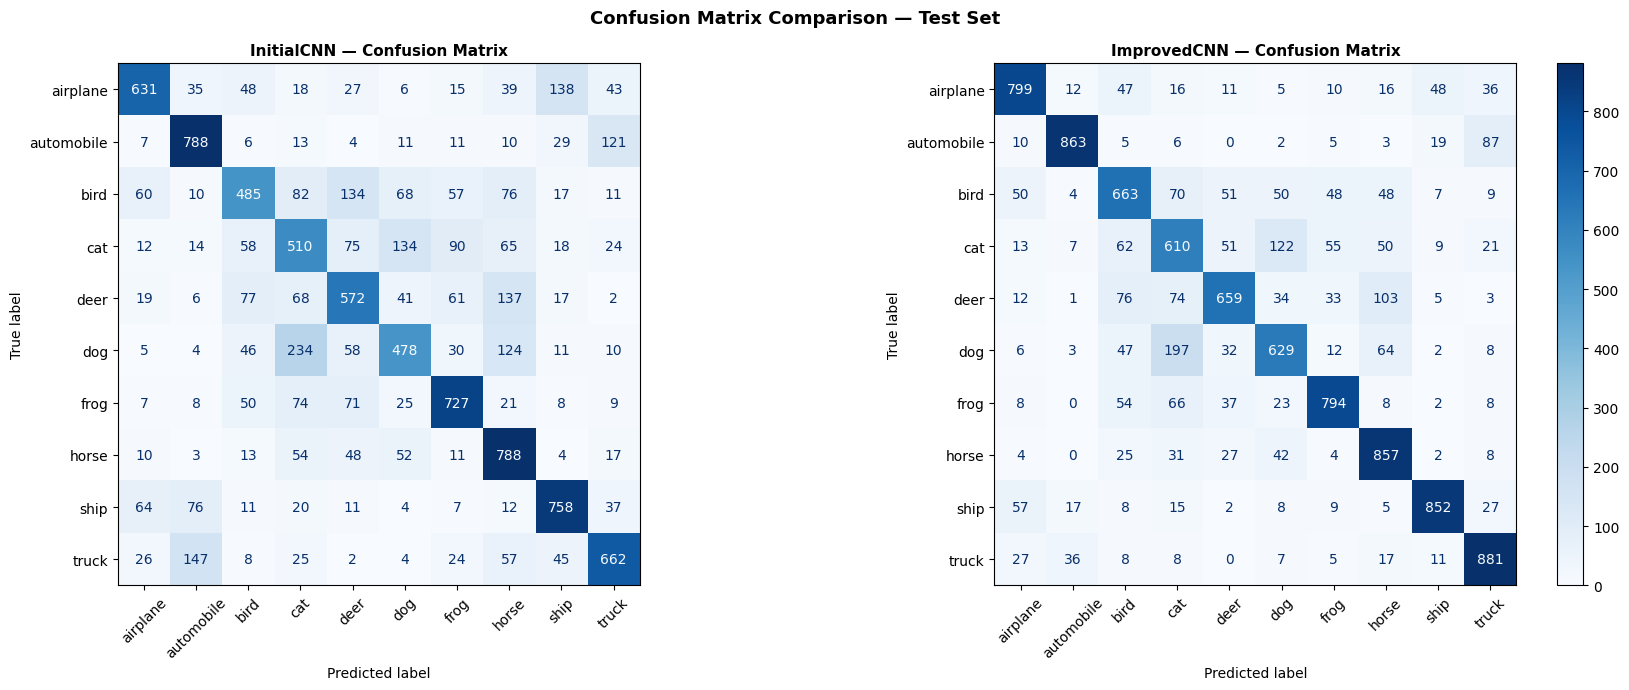

Saved: confusion_matrix_comparison.png


In [17]:
# ── Cell E2: Evaluation Metrics — ImprovedCNN ─────────────────────────────────
# get_predictions() defined in Cell E1 above

y_true_imp, y_pred_imp, y_probs_imp = get_predictions(improved_model, test_loader)

# ── F1 Score ──────────────────────────────────────────────────────────────────
f1_per_class_imp = f1_score(y_true_imp, y_pred_imp, average=None)
f1_macro_imp     = f1_score(y_true_imp, y_pred_imp, average='macro')

print('ImprovedCNN — F1 Score per class:')
print('-' * 35)
for name, f1 in zip(classes, f1_per_class_imp):
    bar = '█' * int(f1 * 20)
    print(f'{name:<12} {f1:.3f}  {bar}')
print(f'\nMacro F1: {f1_macro_imp:.3f}')

# ── F1 comparison side by side ────────────────────────────────────────────────
print('\nF1 Comparison — InitialCNN vs ImprovedCNN:')
print(f'{"Class":<12} {"Initial":>8} {"Improved":>9} {"Change":>8}')
print('-' * 42)
for name, f1_i, f1_m in zip(classes, f1_per_class, f1_per_class_imp):
    diff = f1_m - f1_i
    sign = '+' if diff > 0 else ''
    print(f'{name:<12} {f1_i:>8.3f} {f1_m:>9.3f} {sign}{diff:>7.3f}')
print(f'{"Macro":<12} {f1_macro:>8.3f} {f1_macro_imp:>9.3f} {"+" if f1_macro_imp > f1_macro else ""}{f1_macro_imp - f1_macro:>7.3f}')

# ── AUC-ROC ───────────────────────────────────────────────────────────────────
auc_per_class_imp = roc_auc_score(
    y_true_imp, y_probs_imp, multi_class='ovr', average=None
)
auc_macro_imp = roc_auc_score(
    y_true_imp, y_probs_imp, multi_class='ovr', average='macro'
)

print('\nImprovedCNN — AUC-ROC per class:')
print('-' * 35)
for name, auc in zip(classes, auc_per_class_imp):
    bar = '█' * int(auc * 20)
    print(f'{name:<12} {auc:.3f}  {bar}')
print(f'\nMacro AUC: {auc_macro_imp:.3f}')

# ── Confusion Matrix side by side ─────────────────────────────────────────────
cm_imp = confusion_matrix(y_true_imp, y_pred_imp)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_init, display_labels=classes)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[0].set_title('InitialCNN — Confusion Matrix', fontsize=11, fontweight='bold')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_imp, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[1].set_title('ImprovedCNN — Confusion Matrix', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_comparison.png')

In [18]:
# ── Cell E: Comparison table ──────────────────────────────────────────────────
print(f"{'Metric':<25} {'InitialCNN':>12} {'ImprovedCNN':>12} {'Change':>10}")
print('-' * 62)

metrics = [
    ('Final Train Loss',     train_losses[-1],  imp_train_losses[-1]),
    ('Final Train Accuracy', train_accs[-1],    imp_train_accs[-1]),
    ('Final Test Accuracy',  test_accs[-1],     imp_test_accs[-1]),
    ('Train/Test Gap',       train_accs[-1] - test_accs[-1],
                             imp_train_accs[-1] - imp_test_accs[-1]),
]

for name, orig, imp in metrics:
    diff = imp - orig
    sign = '+' if diff > 0 else ''
    if 'Loss' in name:
        print(f"{name:<25} {orig:>12.4f} {imp:>12.4f} {sign}{diff:>9.4f}")
    else:
        print(f"{name:<25} {orig:>11.2f}% {imp:>11.2f}% {sign}{diff:>8.2f}%")

Metric                      InitialCNN  ImprovedCNN     Change
--------------------------------------------------------------
Final Train Loss                0.9098       0.1528   -0.7569
Final Train Accuracy            67.77%       94.66% +   26.88%
Final Test Accuracy             63.99%       76.07% +   12.08%
Train/Test Gap                   3.78%       18.59% +   14.80%


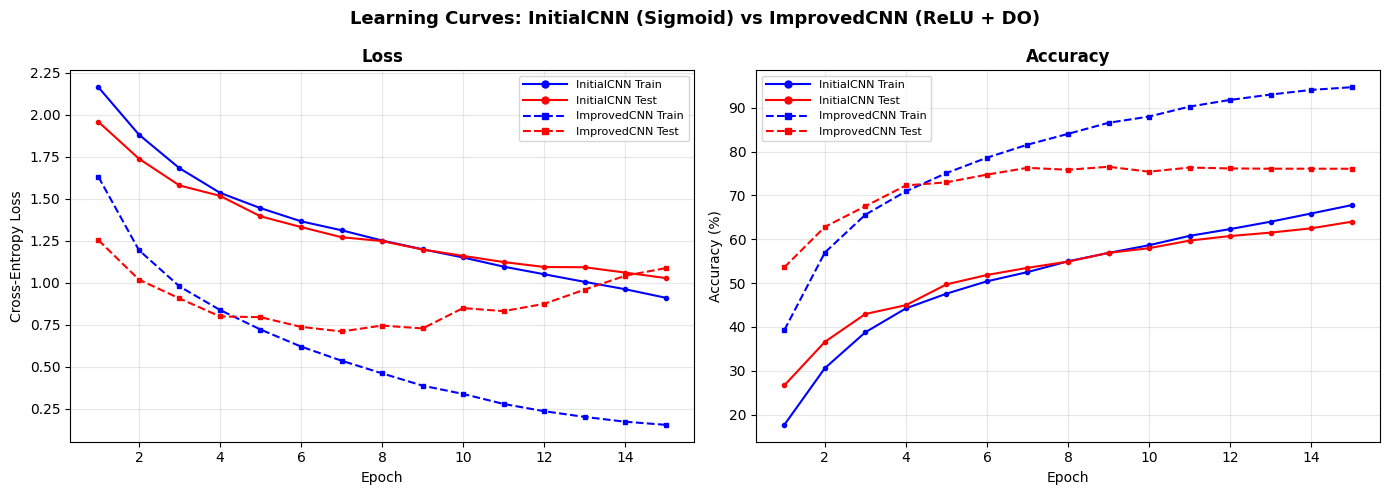

Saved: comparison_learning_curves.png


In [19]:
# ── Cell F: Learning curves — InitialCNN vs ImprovedCNN on same plots ─────────
from matplotlib.lines import Line2D

epochs = range(1, num_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: InitialCNN (Sigmoid) vs ImprovedCNN (ReLU + DO)',
             fontsize=13, fontweight='bold')

# ── Loss ──────────────────────────────────────────────────────────────────────
ax1.plot(epochs, train_losses,     'b-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs, test_losses,      'r-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs, imp_train_losses, 'b--s', markersize=3, linewidth=1.5)
ax1.plot(epochs, imp_test_losses,  'r--s', markersize=3, linewidth=1.5)
ax1.set_title('Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(epochs, train_accs,     'b-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs, test_accs,      'r-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs, imp_train_accs, 'b--s', markersize=3, linewidth=1.5)
ax2.plot(epochs, imp_test_accs,  'r--s', markersize=3, linewidth=1.5)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color='b', linestyle='-',  marker='o', markersize=5, label='InitialCNN Train'),
    Line2D([0], [0], color='r', linestyle='-',  marker='o', markersize=5, label='InitialCNN Test'),
    Line2D([0], [0], color='b', linestyle='--', marker='s', markersize=5, label='ImprovedCNN Train'),
    Line2D([0], [0], color='r', linestyle='--', marker='s', markersize=5, label='ImprovedCNN Test'),
]
ax1.legend(handles=legend_elements, fontsize=8, handlelength=4)
ax2.legend(handles=legend_elements, fontsize=8, handlelength=4)

plt.tight_layout()
plt.savefig('comparison_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_learning_curves.png')

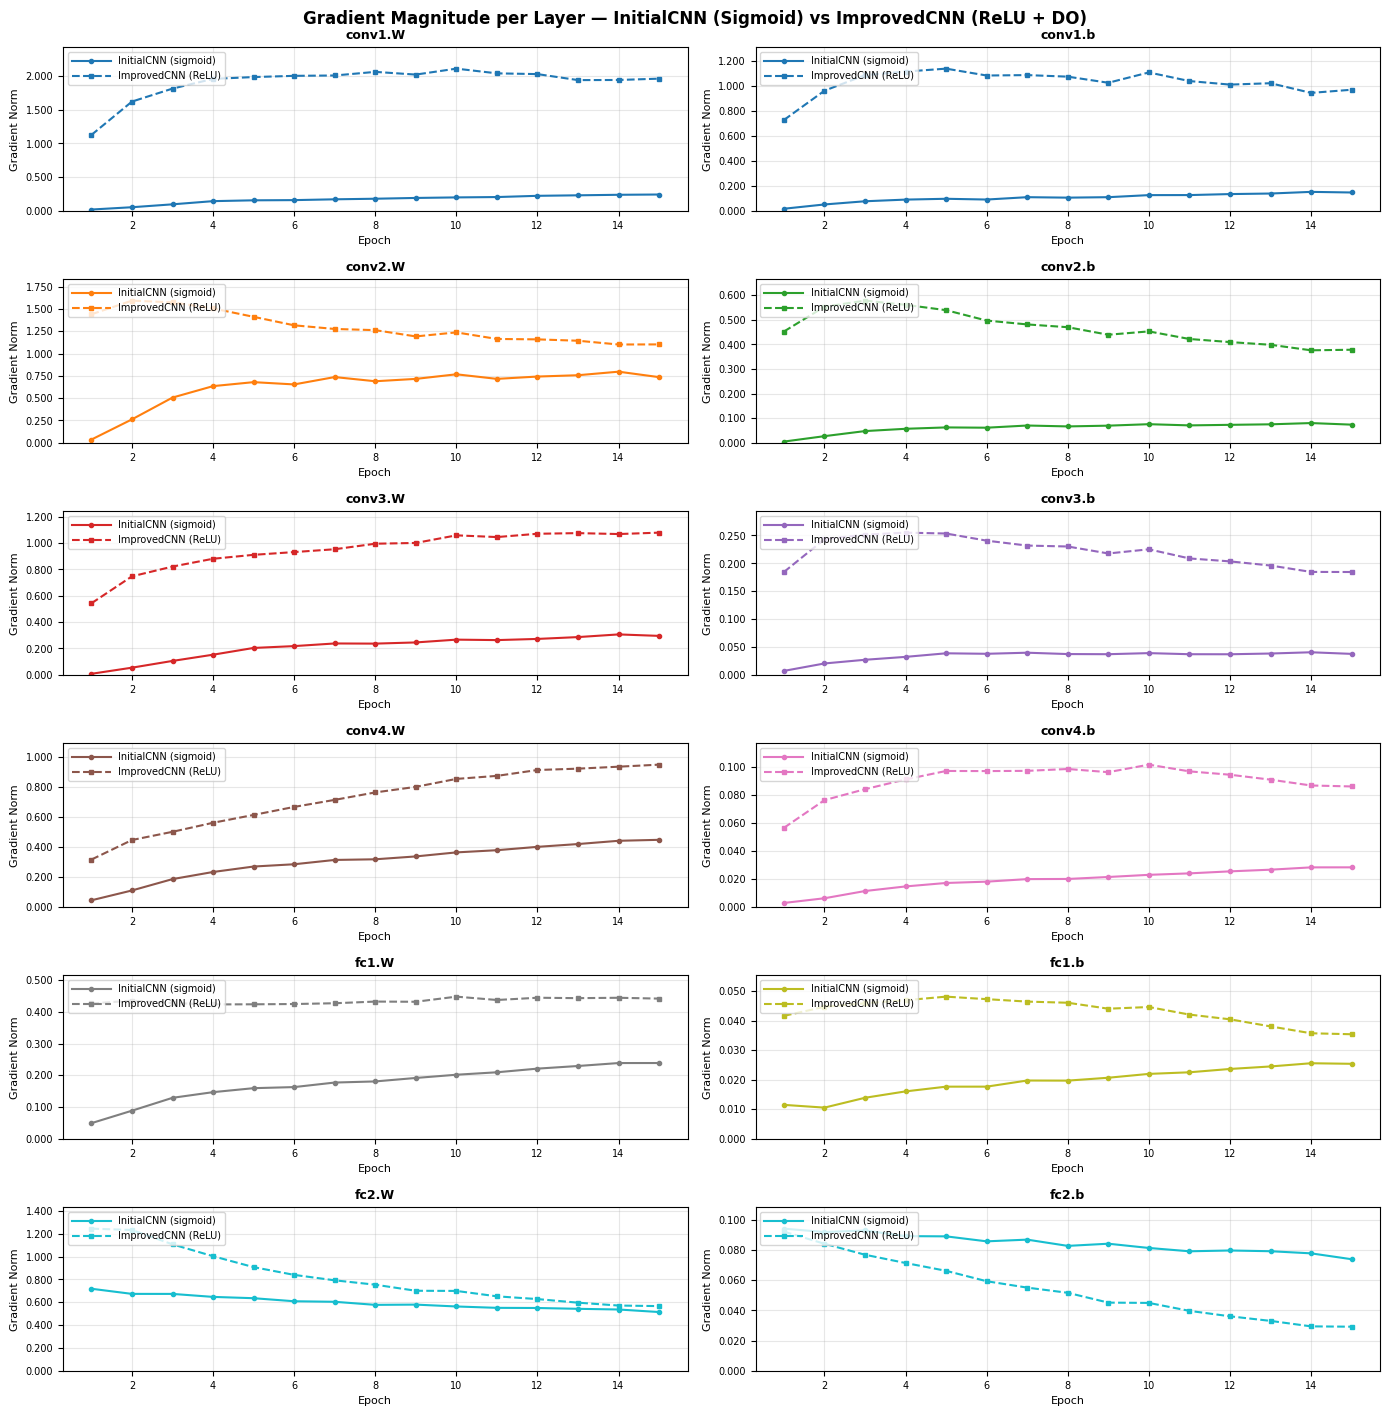

Saved: combined_gradient_magnitudes.png


In [20]:
# ── Cell H: Combined Gradient Magnitudes — InitialCNN vs ImprovedCNN ──────────
# Same y-axis scale as individual plots above — direct visual comparison

layer_names  = list(all_epoch_grad_norms[0].keys())
n_layers     = len(layer_names)
short_labels = [n.replace('.weight', '.W').replace('.bias', '.b') for n in layer_names]

grad_matrix_init = np.array([[all_epoch_grad_norms[e][l] for e in range(num_epochs)]
                              for l in layer_names])
grad_matrix_imp  = np.array([[imp_grad_norms[e][l] for e in range(num_epochs)]
                              for l in layer_names])

y_maxes = np.maximum(grad_matrix_init.max(axis=1), grad_matrix_imp.max(axis=1)) * 1.15

epochs = range(1, num_epochs + 1)
n_cols = 2
n_rows = (n_layers + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.4))
fig.suptitle('Gradient Magnitude per Layer — InitialCNN (Sigmoid) vs ImprovedCNN (ReLU + DO)',
             fontsize=12, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, n_layers))

for i, (label, color) in enumerate(zip(short_labels, colors)):
    row = i // n_cols
    col = i % n_cols
    ax  = axes[row, col]

    ax.plot(epochs, grad_matrix_init[i], color=color,
            linestyle='-', marker='o', markersize=3, linewidth=1.5,
            label='InitialCNN (sigmoid)')
    ax.plot(epochs, grad_matrix_imp[i], color=color,
            linestyle='--', marker='s', markersize=3, linewidth=1.5,
            label='ImprovedCNN (ReLU)')

    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Gradient Norm', fontsize=8)
    ax.set_ylim(0, y_maxes[i])
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper left', handlelength=4)
    ax.grid(True, alpha=0.3)

if n_layers % 2 != 0:
    axes[-1, -1].set_visible(False)

plt.tight_layout()
plt.savefig('combined_gradient_magnitudes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: combined_gradient_magnitudes.png')

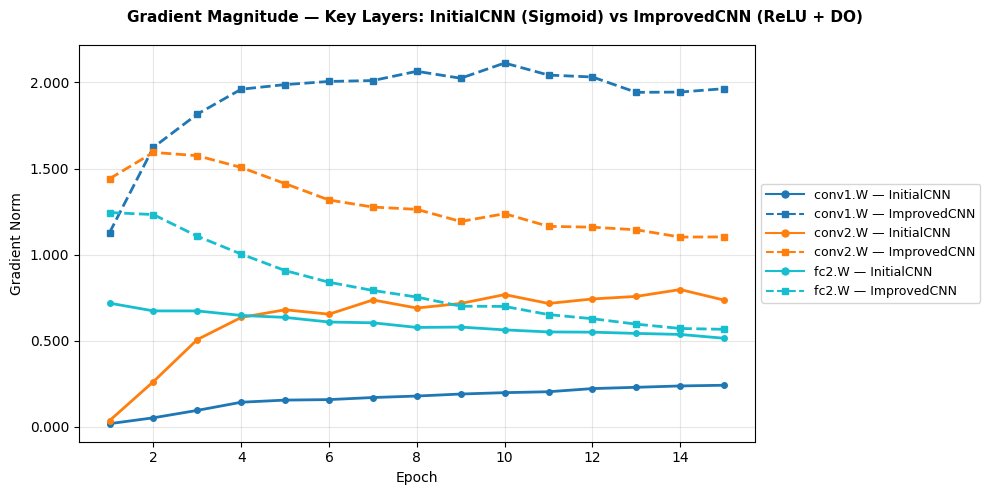

Saved: key_layers_gradient_comparison.png


In [21]:
# ── Cell H2: Key layers comparison — conv1.W, conv2.W, fc2.W ─────────────────
from matplotlib.lines import Line2D

# Use same color mapping as Cell 8
colors = plt.cm.tab10(np.linspace(0, 1, len(layer_names)))
color_map = {name: colors[i] for i, name in enumerate(short_labels)}

key_layers  = ['conv1.weight', 'conv2.weight', 'fc2.weight']
key_labels  = ['conv1.W', 'conv2.W', 'fc2.W']
key_indices = [layer_names.index(l) for l in key_layers]

epochs = range(1, num_epochs + 1)
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gradient Magnitude — Key Layers: InitialCNN (Sigmoid) vs ImprovedCNN (ReLU + DO)',
             fontsize=11, fontweight='bold')

for idx, label in zip(key_indices, key_labels):
    color = color_map[label]
    ax.plot(epochs, grad_matrix_init[idx], color=color,
            linestyle='-', marker='o', markersize=4, linewidth=2)
    ax.plot(epochs, grad_matrix_imp[idx], color=color,
            linestyle='--', marker='s', markersize=4, linewidth=2)

ax.set_xlabel('Epoch', fontsize=10)
ax.set_ylabel('Gradient Norm', fontsize=10)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax.grid(True, alpha=0.3)

legend_elements = []
for label in key_labels:
    color = color_map[label]
    legend_elements.append(
        Line2D([0], [0], color=color, linestyle='-',  marker='o',
               markersize=5, label=f'{label} — InitialCNN'))
    legend_elements.append(
        Line2D([0], [0], color=color, linestyle='--', marker='s',
               markersize=5, label=f'{label} — ImprovedCNN'))

ax.legend(handles=legend_elements, fontsize=9, handlelength=3,
          loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('key_layers_gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: key_layers_gradient_comparison.png')

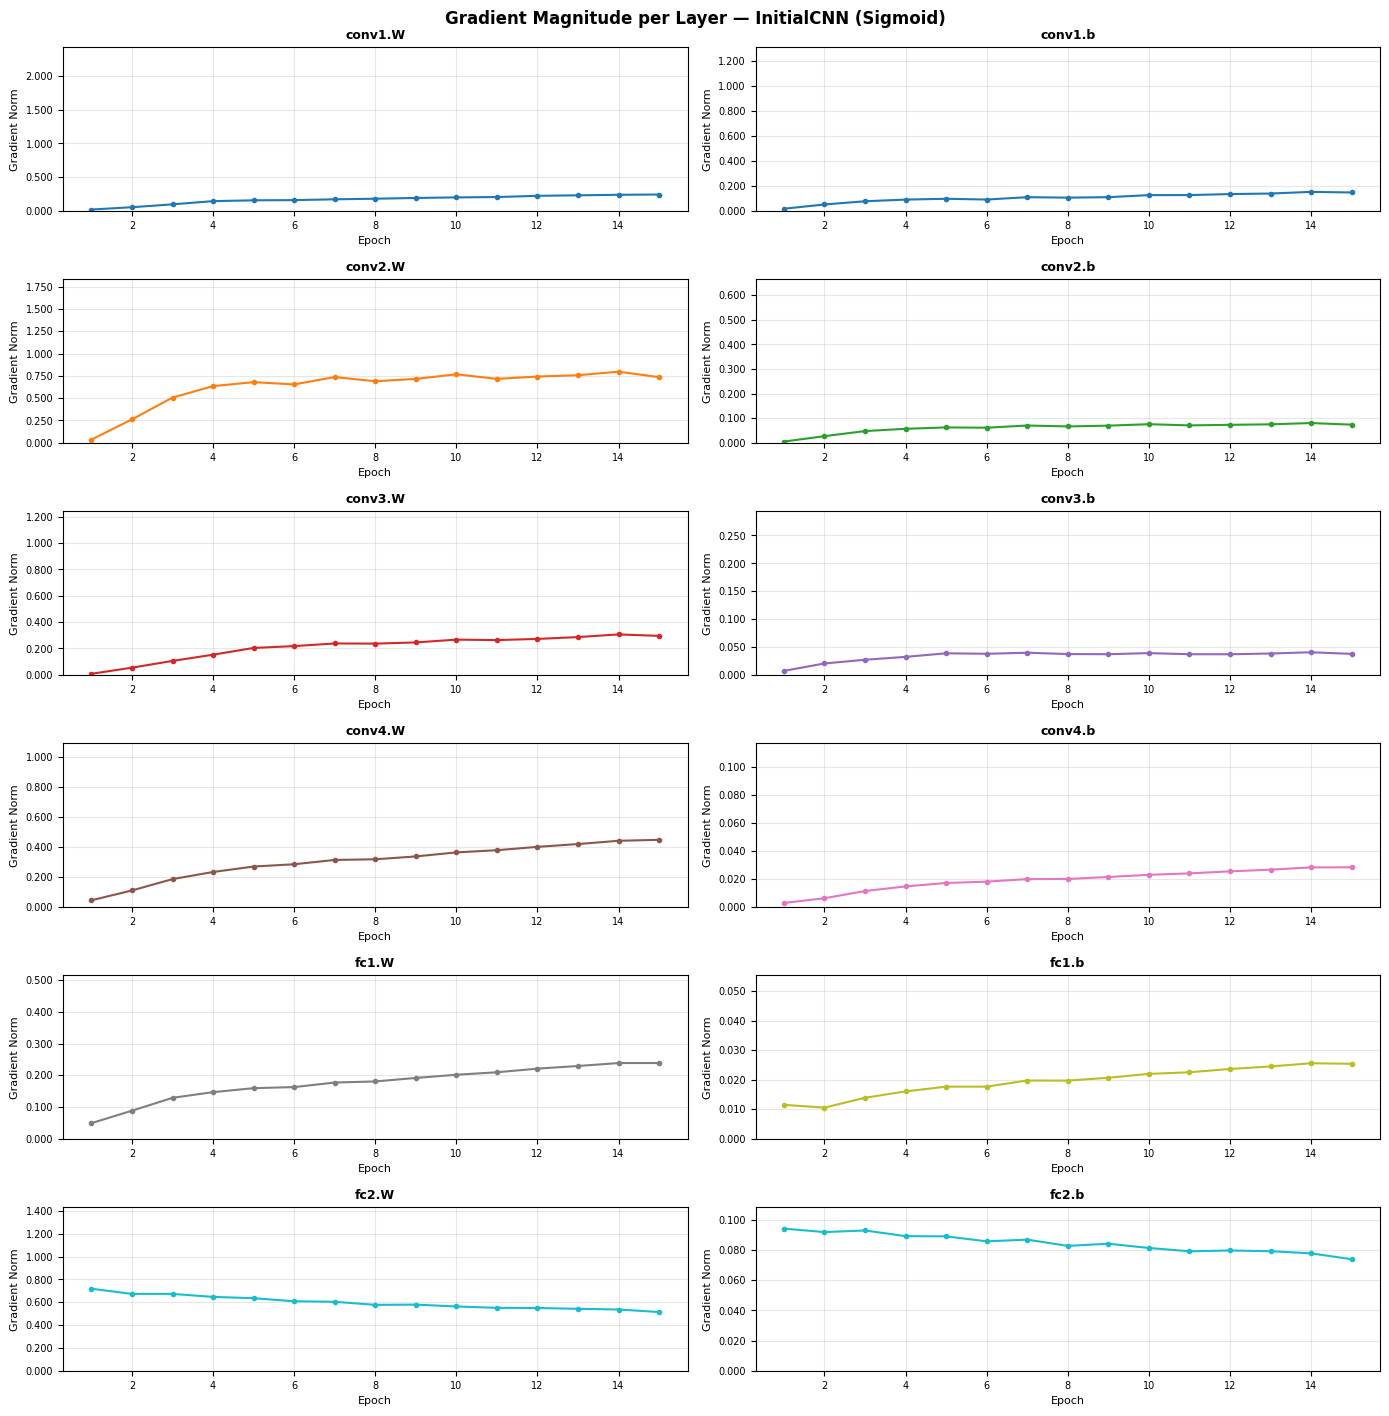

Saved: initial_gradient_magnitudes.png


In [22]:
# ── Cell 8: InitialCNN Gradient Magnitudes (y-axis matched to combined plot) ──
# NOTE: imp_grad_norms must exist in memory (run Cell D first, or load results) so moved to here

layer_names  = list(all_epoch_grad_norms[0].keys())
n_layers     = len(layer_names)
short_labels = [n.replace('.weight', '.W').replace('.bias', '.b') for n in layer_names]

grad_matrix_init = np.array([[all_epoch_grad_norms[e][l] for e in range(num_epochs)]
                              for l in layer_names])
grad_matrix_imp  = np.array([[imp_grad_norms[e][l] for e in range(num_epochs)]
                              for l in layer_names])

# Shared y-axis max across both models per layer
y_maxes = np.maximum(grad_matrix_init.max(axis=1), grad_matrix_imp.max(axis=1)) * 1.15

epochs = range(1, num_epochs + 1)
n_cols = 2
n_rows = (n_layers + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.4))
fig.suptitle('Gradient Magnitude per Layer — InitialCNN (Sigmoid)',
             fontsize=12, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, n_layers))

for i, (label, color) in enumerate(zip(short_labels, colors)):
    row = i // n_cols
    col = i % n_cols
    ax  = axes[row, col]
    ax.plot(epochs, grad_matrix_init[i], color=color,
            linestyle='-', marker='o', markersize=3, linewidth=1.5)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Gradient Norm', fontsize=8)
    ax.set_ylim(0, y_maxes[i])
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

if n_layers % 2 != 0:
    axes[-1, -1].set_visible(False)

plt.tight_layout()
plt.savefig('initial_gradient_magnitudes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: initial_gradient_magnitudes.png')

---
## Part 3: MLP Comparison
Compares InitialMLP against ImprovedCNN across accuracy, parameters, training speed, memory and weight interpretability.

In [23]:
# ── Cell M1: Define and initialise InitialMLP ────────────────────────────────
import time
import tracemalloc

class InitialMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten image to 1D vector
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

mlp_model     = InitialMLP().to(device)
mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

print('InitialMLP ready.')
print(mlp_model)

InitialMLP ready.
InitialMLP(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [24]:
# ── Cell M2: Parameter count comparison ──────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters())

imp_params = count_params(improved_model)
mlp_params = count_params(mlp_model)

print(f'ImprovedCNN parameters: {imp_params:>10,}')
print(f'InitialMLP  parameters: {mlp_params:>10,}')
print(f'Difference             : {mlp_params - imp_params:>+10,}')

ImprovedCNN parameters:    653,386
InitialMLP  parameters:  1,707,274
Difference             : +1,053,888


In [25]:
# ── Cell M3: MLP train/test functions ────────────────────────────────────────
def train_mlp(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mlp_optimizer.zero_grad()
        outputs = model(images)
        loss    = mlp_criterion(outputs, labels)
        loss.backward()
        mlp_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

def test_mlp(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = mlp_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total

print('MLP functions ready.')

MLP functions ready.


In [26]:
# ── Cell M4: Train MLP — measure time and memory ─────────────────────────────
num_epochs = 15
mlp_train_losses, mlp_test_losses = [], []
mlp_train_accs,   mlp_test_accs   = [], []
mlp_epoch_times                   = []

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}  {'Time(s)':>8}")
print('-' * 65)

tracemalloc.start()

for epoch in range(num_epochs):
    t0 = time.time()
    tr_loss, tr_acc = train_mlp(mlp_model, train_loader)
    te_loss, te_acc = test_mlp(mlp_model, test_loader)
    epoch_time      = time.time() - t0

    mlp_train_losses.append(tr_loss);  mlp_test_losses.append(te_loss)
    mlp_train_accs.append(tr_acc);     mlp_test_accs.append(te_acc)
    mlp_epoch_times.append(epoch_time)

    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {te_loss:>9.4f}  {te_acc:>7.2f}%  {epoch_time:>7.1f}s")

_, mlp_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'\nFinal Train Accuracy : {mlp_train_accs[-1]:.2f}%')
print(f'Final Test  Accuracy : {mlp_test_accs[-1]:.2f}%')
print(f'Final Train Loss     : {mlp_train_losses[-1]:.4f}')
print(f'Avg time per epoch   : {np.mean(mlp_epoch_times):.1f}s')
print(f'Peak memory (MLP)    : {mlp_peak_mem / 1024**2:.1f} MB')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc   Time(s)
-----------------------------------------------------------------
    1      1.6287     42.20%     1.4698    48.15%     32.8s
    2      1.4109     50.23%     1.4259    49.30%     33.8s
    3      1.2981     54.26%     1.3630    52.16%     33.5s
    4      1.2050     57.53%     1.3686    52.78%     32.9s
    5      1.1172     60.52%     1.3475    53.15%     34.1s
    6      1.0368     63.35%     1.3478    54.13%     34.4s
    7      0.9578     65.93%     1.3772    54.19%     34.2s
    8      0.8837     68.70%     1.4284    54.11%     34.4s
    9      0.8088     71.26%     1.4953    53.66%     34.9s
   10      0.7292     74.24%     1.5275    53.68%     34.3s
   11      0.6623     76.63%     1.5868    53.97%     33.9s
   12      0.6044     78.61%     1.7483    52.48%     34.3s
   13      0.5409     80.80%     1.7478    53.86%     35.1s
   14      0.4870     82.81%     1.8643    52.85%     34.4s
   15      0.4407     84.42%     1

In [27]:
# ── Cell M5: Timing and memory comparison — works on CPU and GPU ──────────────
import psutil, os

def measure_epoch(model, loader, optimizer, criterion):
    """Run one training epoch and measure time + memory."""

    # ── reset memory tracking ─────────────────────────────────────────────────
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    else:
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2

    t0 = time.time()
    model.train()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    epoch_time = time.time() - t0

    # ── measure memory ────────────────────────────────────────────────────────
    if torch.cuda.is_available():
        mem_used = torch.cuda.max_memory_allocated() / 1024**2
        mem_type = 'GPU VRAM'
    else:
        mem_used = process.memory_info().rss / 1024**2 - mem_before
        mem_type = 'CPU RAM'

    return epoch_time, mem_used, mem_type

cnn_time, cnn_mem, mem_type = measure_epoch(
    improved_model, train_loader, improved_optimizer, improved_criterion)
mlp_time, mlp_mem, _        = measure_epoch(
    mlp_model, train_loader, mlp_optimizer, mlp_criterion)

print(f'ImprovedCNN time per epoch : {cnn_time:.1f}s')
print(f'MLP         time per epoch : {mlp_time:.1f}s')
print(f'Speed ratio (CNN/MLP)      : {cnn_time/mlp_time:.2f}x')
print(f'Memory type measured       : {mem_type}')
print(f'ImprovedCNN peak memory    : {cnn_mem:.1f} MB')
print(f'MLP         peak memory    : {mlp_mem:.1f} MB')

ImprovedCNN time per epoch : 12.8s
MLP         time per epoch : 12.2s
Speed ratio (CNN/MLP)      : 1.04x
Memory type measured       : GPU VRAM
ImprovedCNN peak memory    : 133.9 MB
MLP         peak memory    : 73.6 MB


MLP — F1 Score per class:
-----------------------------------
airplane     0.574  ███████████
automobile   0.642  ████████████
bird         0.439  ████████
cat          0.376  ███████
deer         0.469  █████████
dog          0.450  ████████
frog         0.603  ████████████
horse        0.588  ███████████
ship         0.656  █████████████
truck        0.576  ███████████

Macro F1: 0.537

Macro AUC-ROC: 0.890

Comparison — ImprovedCNN vs MLP:
Class          CNN F1   MLP F1   Change
----------------------------------------
airplane        0.805    0.574  -0.230
automobile      0.888    0.642  -0.246
bird            0.665    0.439  -0.226
cat             0.583    0.376  -0.207
deer            0.705    0.469  -0.236
dog             0.655    0.450  -0.205
frog            0.804    0.603  -0.201
horse           0.789    0.588  -0.201
ship            0.871    0.656  -0.215
truck           0.844    0.576  -0.268
----------------------------------------
Macro F1        0.761    0.537   -0.224
M

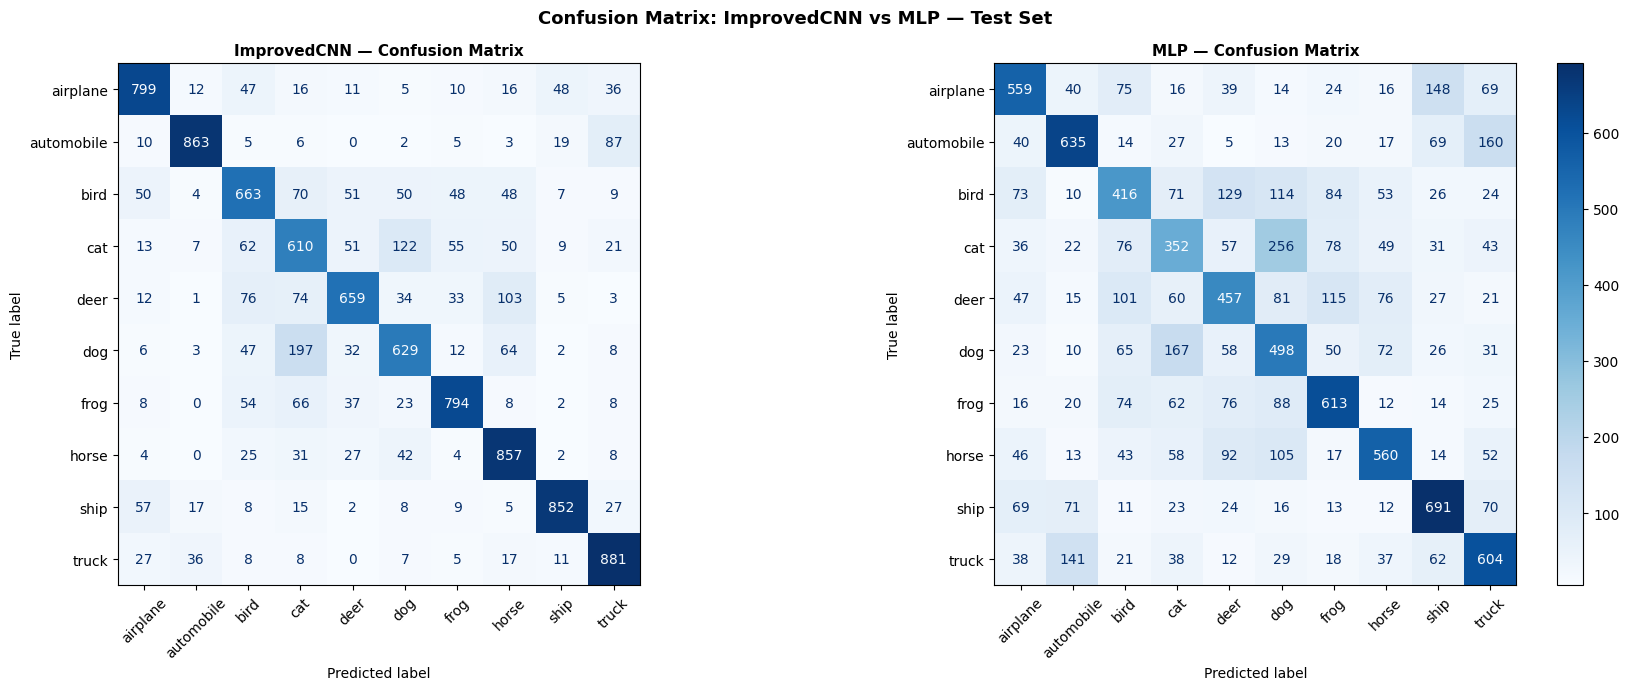

Saved: confusion_matrix_cnn_vs_mlp.png


In [28]:
# ── Cell E3: Evaluation Metrics — MLP ────────────────────────────────────────
y_true_mlp, y_pred_mlp, y_probs_mlp = get_predictions(mlp_model, test_loader)

# ── F1 Score ──────────────────────────────────────────────────────────────────
f1_per_class_mlp = f1_score(y_true_mlp, y_pred_mlp, average=None)
f1_macro_mlp     = f1_score(y_true_mlp, y_pred_mlp, average='macro')

print('MLP — F1 Score per class:')
print('-' * 35)
for name, f1 in zip(classes, f1_per_class_mlp):
    bar = '█' * int(f1 * 20)
    print(f'{name:<12} {f1:.3f}  {bar}')
print(f'\nMacro F1: {f1_macro_mlp:.3f}')

# ── AUC-ROC ───────────────────────────────────────────────────────────────────
auc_macro_mlp = roc_auc_score(
    y_true_mlp, y_probs_mlp, multi_class='ovr', average='macro'
)
print(f'\nMacro AUC-ROC: {auc_macro_mlp:.3f}')

# ── F1 + AUC Comparison — ImprovedCNN vs MLP ─────────────────────────────────
print('\nComparison — ImprovedCNN vs MLP:')
print(f'{"Class":<12} {"CNN F1":>8} {"MLP F1":>8} {"Change":>8}')
print('-' * 40)
for name, f1_imp, f1_mlp in zip(classes, f1_per_class_imp, f1_per_class_mlp):
    diff = f1_mlp - f1_imp
    sign = '+' if diff > 0 else ''
    print(f'{name:<12} {f1_imp:>8.3f} {f1_mlp:>8.3f} {sign}{diff:>7.3f}')
print('-' * 40)
print(f'{"Macro F1":<12} {f1_macro_imp:>8.3f} {f1_macro_mlp:>8.3f} {f1_macro_mlp - f1_macro_imp:>+8.3f}')
print(f'{"Macro AUC":<12} {auc_macro_imp:>8.3f} {auc_macro_mlp:>8.3f} {auc_macro_mlp - auc_macro_imp:>+8.3f}')

# ── Confusion Matrix — side by side ──────────────────────────────────────────
cm_mlp = confusion_matrix(y_true_mlp, y_pred_mlp)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_imp, display_labels=classes)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[0].set_title('ImprovedCNN — Confusion Matrix', fontsize=11, fontweight='bold')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[1].set_title('MLP — Confusion Matrix', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix: ImprovedCNN vs MLP — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cnn_vs_mlp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_cnn_vs_mlp.png')


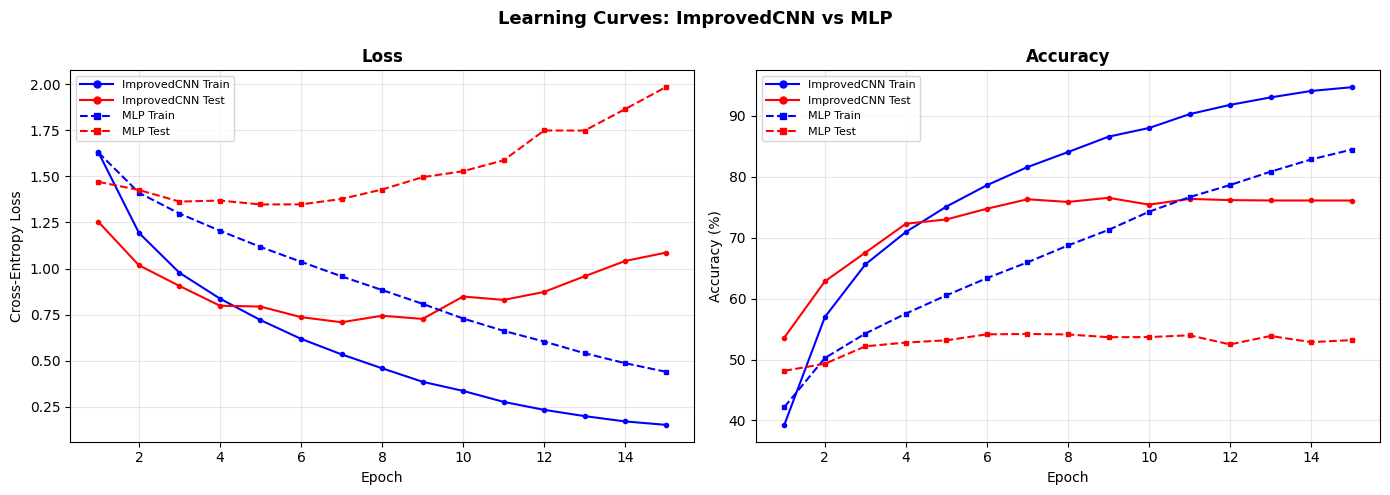

Saved: mlp_vs_cnn_curves.png


In [29]:
# ── Cell M6: Learning curves — ImprovedCNN vs MLP ────────────────────────────
from matplotlib.lines import Line2D
epochs = range(1, num_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: ImprovedCNN vs MLP', fontsize=13, fontweight='bold')

ax1.plot(epochs, imp_train_losses, 'b-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs, imp_test_losses,  'r-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs, mlp_train_losses, 'b--s', markersize=3, linewidth=1.5)
ax1.plot(epochs, mlp_test_losses,  'r--s', markersize=3, linewidth=1.5)
ax1.set_title('Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, imp_train_accs, 'b-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs, imp_test_accs,  'r-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs, mlp_train_accs, 'b--s', markersize=3, linewidth=1.5)
ax2.plot(epochs, mlp_test_accs,  'r--s', markersize=3, linewidth=1.5)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

legend_elements = [
    Line2D([0], [0], color='b', linestyle='-',  marker='o', markersize=5, label='ImprovedCNN Train'),
    Line2D([0], [0], color='r', linestyle='-',  marker='o', markersize=5, label='ImprovedCNN Test'),
    Line2D([0], [0], color='b', linestyle='--', marker='s', markersize=5, label='MLP Train'),
    Line2D([0], [0], color='r', linestyle='--', marker='s', markersize=5, label='MLP Test'),
]
ax1.legend(handles=legend_elements, fontsize=8, handlelength=3)
ax2.legend(handles=legend_elements, fontsize=8, handlelength=3)

plt.tight_layout()
plt.savefig('mlp_vs_cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mlp_vs_cnn_curves.png')

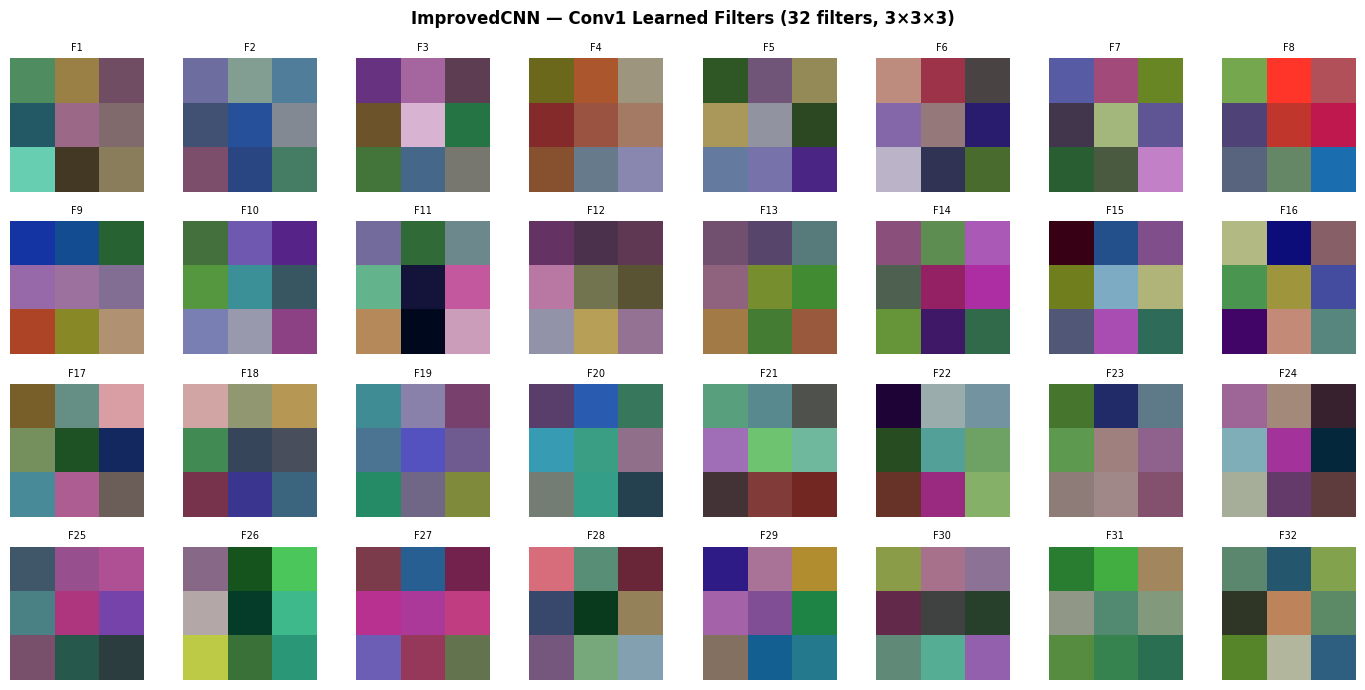

Saved: cnn_conv1_filters.png


In [30]:
# ── Cell M7: Weight visualisation — ImprovedCNN conv1 filters ────────────────
weights = improved_model.conv1.weight.data.cpu()  # shape: (32, 3, 3, 3)
w_min, w_max = weights.min(), weights.max()
weights_norm = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('ImprovedCNN — Conv1 Learned Filters (32 filters, 3×3×3)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 32:
        filt = weights_norm[i].permute(1, 2, 0).numpy()
        ax.imshow(filt)
        ax.set_title(f'F{i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_conv1_filters.png')

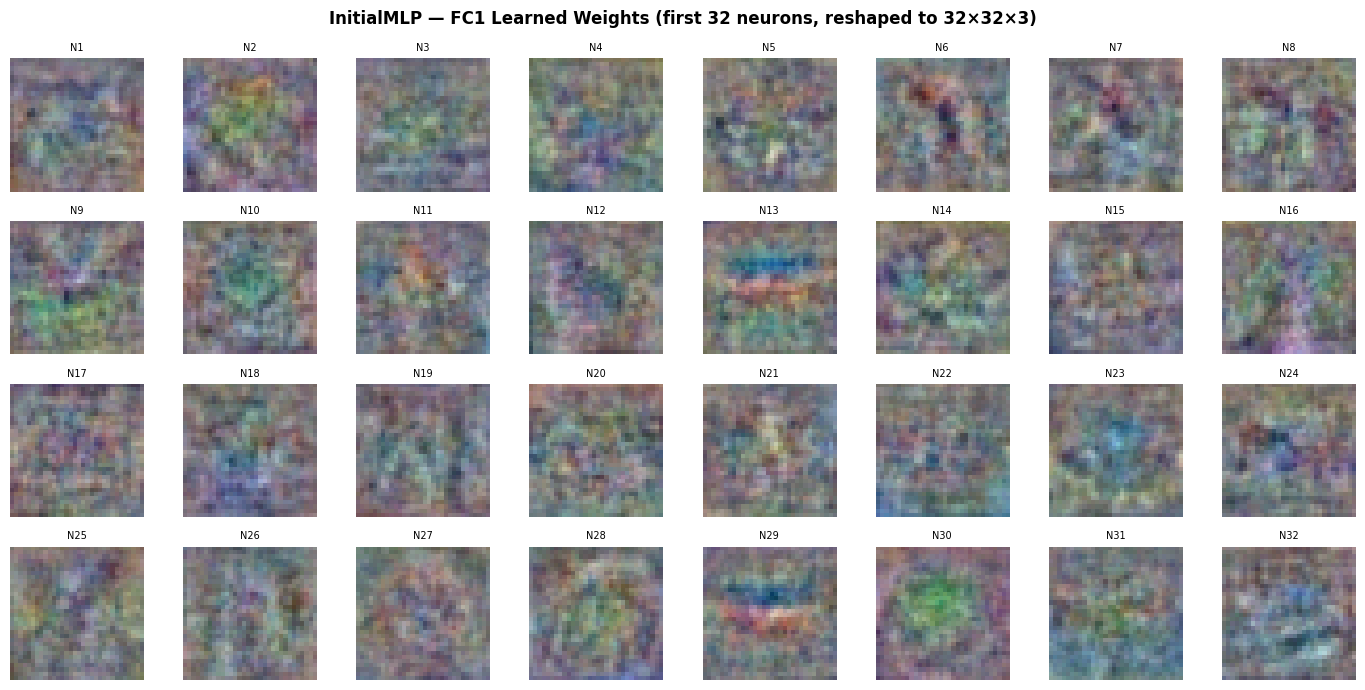

Saved: mlp_fc1_weights.png


In [31]:
# ── Cell M8: Weight visualisation — MLP fc1 weights ──────────────────────────
weights_mlp = mlp_model.fc1.weight.data.cpu()  # shape: (512, 3072)
w_min, w_max = weights_mlp.min(), weights_mlp.max()
weights_norm = (weights_mlp - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('InitialMLP — FC1 Learned Weights (first 32 neurons, reshaped to 32×32×3)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 32:
        neuron = weights_norm[i].reshape(3, 32, 32).permute(1, 2, 0).numpy()
        ax.imshow(neuron)
        ax.set_title(f'N{i+1}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('mlp_fc1_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mlp_fc1_weights.png')

In [32]:
# ── Cell M9: Full comparison summary ─────────────────────────────────────────
print('=' * 55)
print(f"{'Metric':<28} {'ImprovedCNN':>12} {'MLP':>10}")
print('=' * 55)
print(f"{'Parameters':<28} {imp_params:>12,} {mlp_params:>10,}")
print(f"{'Final Test Accuracy':<28} {imp_test_accs[-1]:>11.2f}% {mlp_test_accs[-1]:>9.2f}%")
print(f"{'Final Train Loss':<28} {imp_train_losses[-1]:>12.4f} {mlp_train_losses[-1]:>10.4f}")
print(f"{'Epoch time (s)':<28} {cnn_time:>11.1f}s {mlp_time:>9.1f}s")
print(f"{'Peak memory (MB)':<28} {cnn_mem:>11.1f} {mlp_mem:>9.1f}")
print('=' * 55)

Metric                        ImprovedCNN        MLP
Parameters                        653,386  1,707,274
Final Test Accuracy                76.07%     53.18%
Final Train Loss                   0.1528     0.4407
Epoch time (s)                      12.8s      12.2s
Peak memory (MB)                   133.9      73.6



OVERFITTING

In [33]:
# ── Cell Q3A: Early Stopping ──────────────────────────────────────────────────
# Hyperparameter: patience = number of epochs to wait before stopping
# We monitor test accuracy and stop when it hasn't improved for 'patience' epochs

patience = 3  # hyperparameter — wait 3 epochs before stopping

es_train_losses, es_test_losses = [], []
es_train_accs,   es_test_accs   = [], []

# Fresh model with same architecture as ImprovedCNN
es_model     = ImprovedCNN().to(device)
es_criterion = nn.CrossEntropyLoss()
es_optimizer = optim.Adam(es_model.parameters(), lr=0.001)

best_test_loss = float('inf')
epochs_no_improve = 0
best_epoch       = 0
stopped_epoch    = 15  # default if no early stop

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}  {'Status':>10}")
print('-' * 65)

for epoch in range(15):
    # Use existing train/test functions
    es_model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        es_optimizer.zero_grad()
        outputs = es_model(images)
        loss    = es_criterion(outputs, labels)
        loss.backward()
        es_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
    tr_loss = running_loss / len(train_loader)
    tr_acc  = 100 * correct / total

    es_model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = es_model(images)
            loss    = es_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    te_loss = running_loss / len(test_loader)
    te_acc  = 100 * correct / total

    es_train_losses.append(tr_loss); es_test_losses.append(te_loss)
    es_train_accs.append(tr_acc);    es_test_accs.append(te_acc)

    # Early stopping logic
    if te_loss < best_test_loss:
      best_test_loss    = te_loss
      best_epoch        = epoch + 1
      epochs_no_improve = 0
      status = 'improved'
    else:
      epochs_no_improve += 1
      status = f'no improve ({epochs_no_improve}/{patience})'

    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {te_loss:>9.4f}  {te_acc:>7.2f}%  {status:>10}")

    if epochs_no_improve >= patience:
        stopped_epoch = epoch + 1
        print(f'\nEarly stopping triggered at epoch {stopped_epoch}.')
        print(f'Best test loss: {best_test_loss:.4f} at epoch {best_epoch}.')
        break

print(f'Best test loss: {best_test_loss:.4f} at epoch {best_epoch}.')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc      Status
-----------------------------------------------------------------
    1      1.6187     39.78%     1.3155    51.92%    improved
    2      1.2211     55.97%     1.0723    60.54%    improved
    3      0.9965     64.87%     0.9058    68.41%    improved
    4      0.8241     71.39%     0.7996    71.90%    improved
    5      0.7134     75.31%     0.7709    73.33%    improved
    6      0.6185     78.55%     0.7592    74.60%    improved
    7      0.5347     81.36%     0.7059    76.31%    improved
    8      0.4639     83.91%     0.7006    77.03%    improved
    9      0.4043     86.14%     0.7548    77.26%  no improve (1/3)
   10      0.3394     88.13%     0.8339    76.22%  no improve (2/3)
   11      0.2904     89.74%     0.7679    77.59%  no improve (3/3)

Early stopping triggered at epoch 11.
Best test loss: 0.7006 at epoch 8.
Best test loss: 0.7006 at epoch 8.


In [34]:
# ── Cell Q3B: Weight Decay ────────────────────────────────────────────────────
# Hyperparameter: weight_decay (lambda) added to Adam optimiser
# Penalises large weights throughout training to prevent memorisation
# Common starting values: 1e-4 (moderate), 1e-5 (mild), 1e-3 (strong)

weight_decay = 1e-3  # was 1e-4 but not sig enough  # hyperparameter — controls strength of regularisation

wd_train_losses, wd_test_losses = [], []
wd_train_accs,   wd_test_accs   = [], []

# Fresh model — same architecture, only optimiser changes
wd_model     = ImprovedCNN().to(device)
wd_criterion = nn.CrossEntropyLoss()
wd_optimizer = optim.Adam(wd_model.parameters(), lr=0.001,
                           weight_decay=weight_decay)  # <-- only change

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}")
print('-' * 52)

for epoch in range(15):
    wd_model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        wd_optimizer.zero_grad()
        outputs = wd_model(images)
        loss    = wd_criterion(outputs, labels)
        loss.backward()
        wd_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
    tr_loss = running_loss / len(train_loader)
    tr_acc  = 100 * correct / total

    wd_model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = wd_model(images)
            loss    = wd_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    te_loss = running_loss / len(test_loader)
    te_acc  = 100 * correct / total

    wd_train_losses.append(tr_loss); wd_test_losses.append(te_loss)
    wd_train_accs.append(tr_acc);    wd_test_accs.append(te_acc)

    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {te_loss:>9.4f}  {te_acc:>7.2f}%")

print(f'\nFinal Train Accuracy : {wd_train_accs[-1]:.2f}%')
print(f'Final Test  Accuracy : {wd_test_accs[-1]:.2f}%')
print(f'Train/Test Gap       : {wd_train_accs[-1] - wd_test_accs[-1]:.2f}%')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc
----------------------------------------------------
    1      1.6681     37.60%     1.3179    51.38%
    2      1.2470     54.77%     1.0993    59.67%
    3      1.0495     62.89%     0.9673    65.87%
    4      0.9163     67.92%     0.8742    69.48%
    5      0.8097     71.91%     0.7822    73.08%
    6      0.7312     74.66%     0.7680    73.88%
    7      0.6731     76.80%     0.6972    75.31%
    8      0.6146     78.96%     0.7148    75.45%
    9      0.5682     80.59%     0.7284    75.57%
   10      0.5311     81.69%     0.7100    76.19%
   11      0.4870     83.37%     0.6929    76.35%
   12      0.4529     84.54%     0.6979    77.18%
   13      0.4153     85.87%     0.6585    78.23%
   14      0.3850     86.77%     0.6730    78.45%
   15      0.3576     87.81%     0.6574    77.76%

Final Train Accuracy : 87.81%
Final Test  Accuracy : 77.76%
Train/Test Gap       : 10.05%


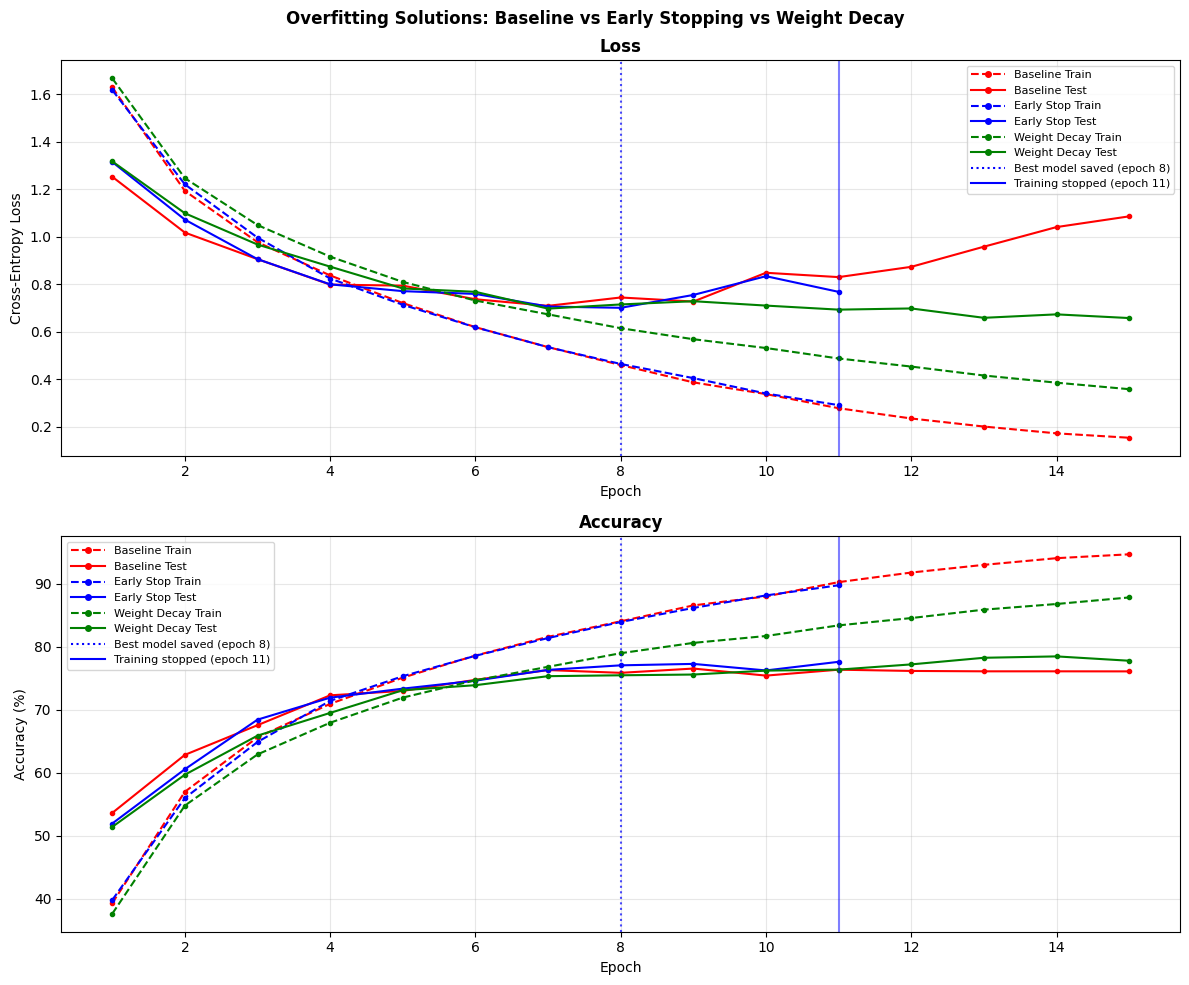

Saved: overfitting_solutions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


In [35]:
# ── Cell Q3C: Comparison plot — baseline vs early stopping vs weight decay ────
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('Overfitting Solutions: Baseline vs Early Stopping vs Weight Decay',
             fontsize=12, fontweight='bold')

base_epochs = range(1, 16)
es_epochs   = range(1, len(es_test_accs) + 1)
wd_epochs   = range(1, 16)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax1.plot(base_epochs, imp_train_losses, 'r--o', markersize=3, linewidth=1.5)
ax1.plot(base_epochs, imp_test_losses,  'r-o',  markersize=3, linewidth=1.5)
ax1.plot(es_epochs,   es_train_losses,  'b--o', markersize=3, linewidth=1.5)
ax1.plot(es_epochs,   es_test_losses,   'b-o',  markersize=3, linewidth=1.5)
ax1.plot(wd_epochs,   wd_train_losses,  'g--o', markersize=3, linewidth=1.5)
ax1.plot(wd_epochs,   wd_test_losses,   'g-o',  markersize=3, linewidth=1.5)
ax1.set_title('Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(base_epochs, imp_train_accs, 'r--o', markersize=3, linewidth=1.5)
ax2.plot(base_epochs, imp_test_accs,  'r-o',  markersize=3, linewidth=1.5)
ax2.plot(es_epochs,   es_train_accs,  'b--o', markersize=3, linewidth=1.5)
ax2.plot(es_epochs,   es_test_accs,   'b-o',  markersize=3, linewidth=1.5)
ax2.plot(wd_epochs,   wd_train_accs,  'g--o', markersize=3, linewidth=1.5)
ax2.plot(wd_epochs,   wd_test_accs,   'g-o',  markersize=3, linewidth=1.5)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

# ── Shared legend ─────────────────────────────────────────────────────────────
ax1.axvline(x=best_epoch,    color='b', linestyle=':', alpha=0.7, linewidth=1.5)
ax1.axvline(x=stopped_epoch, color='b', linestyle='-', alpha=0.5, linewidth=1.5)
ax2.axvline(x=best_epoch,    color='b', linestyle=':', alpha=0.7, linewidth=1.5)
ax2.axvline(x=stopped_epoch, color='b', linestyle='-', alpha=0.5, linewidth=1.5)

legend_elements = [
    Line2D([0],[0], color='r', linestyle='--', marker='o', markersize=4, label='Baseline Train'),
    Line2D([0],[0], color='r', linestyle='-',  marker='o', markersize=4, label='Baseline Test'),
    Line2D([0],[0], color='b', linestyle='--', marker='o', markersize=4, label='Early Stop Train'),
    Line2D([0],[0], color='b', linestyle='-',  marker='o', markersize=4, label='Early Stop Test'),
    Line2D([0],[0], color='g', linestyle='--', marker='o', markersize=4, label='Weight Decay Train'),
    Line2D([0],[0], color='g', linestyle='-',  marker='o', markersize=4, label='Weight Decay Test'),
    Line2D([0],[0], color='b', linestyle=':',  linewidth=1.5, label=f'Best model saved (epoch {best_epoch})'),
    Line2D([0],[0], color='b', linestyle='-',  linewidth=1.5, label=f'Training stopped (epoch {stopped_epoch})'),
]
ax1.legend(handles=legend_elements, fontsize=8, handlelength=3)
ax2.legend(handles=legend_elements, fontsize=8, handlelength=3)
plt.tight_layout()
plt.savefig('overfitting_solutions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: overfitting_solutions.png')

# ── Download in Colab ─────────────────────────────────────────────────────────
try:
    from google.colab import files
    files.download('overfitting_solutions.png')
    print('Download started.')
except ImportError:
    print('Not in Colab — saved locally as overfitting_solutions.png')

 PART 4 - AUGMENTATION

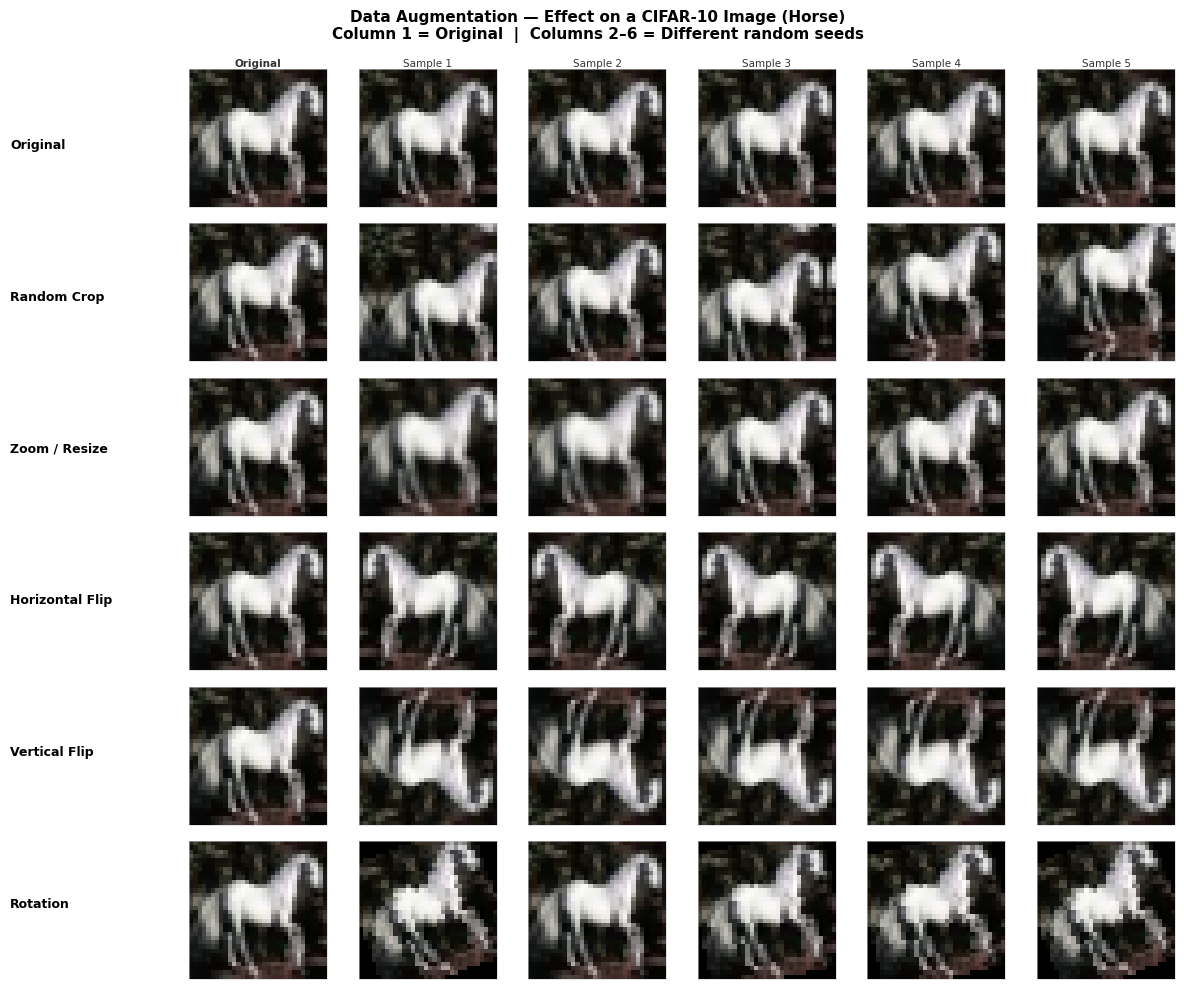

Saved: augmentation_all_transforms.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# ── Cell AUG_VIS: Visualise ALL augmentations (standalone, no side effects) ────
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2434, 0.2615)

def denorm(t):
    t = t.clone()
    for c, (m, s) in enumerate(zip(CIFAR_MEAN, CIFAR_STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

# ── Collect one sample image (horse — clear shape) ────────────────────────────
demo_class = 7  # 0=airplane 1=auto 2=bird 3=cat 4=deer 5=dog 6=frog 7=horse 8=ship 9=truck
sample_imgs = {}
for img, lbl in test_dataset_norm:
    if lbl not in sample_imgs:
        sample_imgs[lbl] = img
    if len(sample_imgs) == 10:
        break

demo_img_tensor = sample_imgs[demo_class]
demo_img_pil    = TF.to_pil_image(denorm(demo_img_tensor))
class_name      = train_dataset_norm.classes[demo_class].capitalize()

# ── Augmentation definitions ──────────────────────────────────────────────────
AUG_NAMES = [
    'Original',
    'Random Crop',
    'Zoom / Resize',
    'Horizontal Flip',
    'Vertical Flip',
    'Rotation',
]

def apply_aug(name, pil_img, seed):
    random.seed(seed)
    if name == 'Original':
        return pil_img.copy()
    elif name == 'Random Crop':
        # Pads image by 4 pixels on each side then crops back to 32×32
        # Simulates slight translation — object shifts position
        return T.RandomCrop(32, padding=4, padding_mode='reflect')(pil_img)
    elif name == 'Zoom / Resize':
        # Crops a random 80–100% region and resizes back to 32×32
        # Simulates zoom-in — object appears larger
        return T.RandomResizedCrop(32, scale=(0.80, 1.0), ratio=(1.0, 1.0))(pil_img)
    elif name == 'Horizontal Flip':
        # Mirrors the image left-right
        return TF.hflip(pil_img)
    elif name == 'Vertical Flip':
        # Mirrors the image top-bottom
        return TF.vflip(pil_img)
    elif name == 'Rotation':
        # Rotates by a random angle between -30 and +30 degrees
        angle = random.uniform(-30, 30) if seed % 2 == 0 else random.uniform(10, 30)
        return TF.rotate(pil_img, angle)

# ── Plot: each row = one augmentation, each column = one sample ───────────────
to_tensor = T.ToTensor()
N_COLS = 6
N_ROWS = len(AUG_NAMES)

fig = plt.figure(figsize=(12, 10))
fig.patch.set_facecolor('white')
fig.suptitle(
    f'Data Augmentation — Effect on a CIFAR-10 Image ({class_name})\n'
    f'Column 1 = Original  |  Columns 2–6 = Different random seeds',
    fontsize=11, fontweight='bold'
)

gs = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig,
                       hspace=0.12, wspace=0.06,
                       left=0.15, right=0.99, top=0.92, bottom=0.01)

row_height = (gs.top - gs.bottom) / N_ROWS

for row, name in enumerate(AUG_NAMES):
    # Row label on the left
    y_center = gs.bottom + (N_ROWS - row - 0.5) * row_height
    fig.text(0.01, y_center, name, ha='left', va='center',
             fontsize=9, fontweight='bold', transform=fig.transFigure)

    for col in range(N_COLS):
        ax   = fig.add_subplot(gs[row, col])
        seed = col * 17 + row * 3 + 1

        # Column 0 always shows the original for reference
        aug_name = 'Original' if col == 0 else name
        aug_pil  = apply_aug(aug_name, demo_img_pil, seed)

        img_show = to_tensor(aug_pil).permute(1, 2, 0).numpy()
        ax.imshow(img_show, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.4); spine.set_edgecolor('#ccc')

        if row == 0:
            ax.set_title(
                'Original' if col == 0 else f'Sample {col}',
                fontsize=7.5,
                fontweight='bold' if col == 0 else 'normal',
                color='#333', pad=2
            )

plt.savefig('augmentation_all_transforms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmentation_all_transforms.png')
try:
    from google.colab import files; files.download('augmentation_all_transforms.png')
except ImportError:
    pass

In [37]:
# ── Cell AUG2: Build augmented training loader ─────────────────────────────────
augmented_transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomResizedCrop(32, scale=(0.80, 1.0), ratio=(1.0, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

aug_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

aug_train_dataset = datasets.CIFAR10(root='./data', train=True,  download=False,
                                      transform=augmented_transform_train)
aug_test_dataset  = datasets.CIFAR10(root='./data', train=False, download=False,
                                      transform=aug_transform_test)

aug_train_loader = DataLoader(aug_train_dataset, batch_size=128, shuffle=True,
                               num_workers=2, pin_memory=True)
aug_test_loader  = DataLoader(aug_test_dataset,  batch_size=128, shuffle=False,
                               num_workers=2, pin_memory=True)

print('Augmented loaders ready.')
print(f'  Train: {len(aug_train_dataset):,} samples | Test: {len(aug_test_dataset):,} samples')
print('Augmentations applied to training set only:')
print('  RandomCrop(32, padding=4) | RandomResizedCrop(scale=0.80\u20131.0) | RandomHorizontalFlip(p=0.5)')
print('  (Rotation and VerticalFlip excluded)')

Augmented loaders ready.
  Train: 50,000 samples | Test: 10,000 samples
Augmentations applied to training set only:
  RandomCrop(32, padding=4) | RandomResizedCrop(scale=0.80–1.0) | RandomHorizontalFlip(p=0.5)
  (Rotation and VerticalFlip excluded)


In [38]:
# ── Cell AUG3: Train AugmentedCNN (same ImprovedCNN architecture) ───────────────
aug_model     = ImprovedCNN().to(device)
aug_criterion = nn.CrossEntropyLoss()
aug_optimizer = optim.Adam(aug_model.parameters(), lr=0.001)

aug_train_losses, aug_test_losses = [], []
aug_train_accs,   aug_test_accs   = [], []

num_epochs = 25
print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}")
print('-' * 52)

for epoch in range(num_epochs):
    aug_model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in aug_train_loader:
        images, labels = images.to(device), labels.to(device)
        aug_optimizer.zero_grad()
        outputs = aug_model(images)
        loss    = aug_criterion(outputs, labels)
        loss.backward()
        aug_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
    tr_loss = running_loss / len(aug_train_loader)
    tr_acc  = 100 * correct / total

    aug_model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in aug_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = aug_model(images)
            loss    = aug_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    te_loss = running_loss / len(aug_test_loader)
    te_acc  = 100 * correct / total

    aug_train_losses.append(tr_loss);  aug_test_losses.append(te_loss)
    aug_train_accs.append(tr_acc);     aug_test_accs.append(te_acc)
    print(f"{epoch+1:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {te_loss:>9.4f}  {te_acc:>7.2f}%")

print(f'\nFinal Train Accuracy : {aug_train_accs[-1]:.2f}%')
print(f'Final Test  Accuracy : {aug_test_accs[-1]:.2f}%')
print(f'Train/Test Gap       : {aug_train_accs[-1] - aug_test_accs[-1]:.2f}%')

Epoch  Train Loss  Train Acc  Test Loss  Test Acc
----------------------------------------------------
    1      1.7225     35.64%     1.3487    49.21%
    2      1.3629     50.42%     1.1709    57.64%
    3      1.1761     58.04%     0.9987    64.27%
    4      1.0473     62.93%     0.9429    67.21%
    5      0.9459     66.95%     0.9107    68.85%
    6      0.8748     69.61%     0.7981    72.76%
    7      0.8153     71.81%     0.7330    74.34%
    8      0.7788     72.99%     0.7467    74.37%
    9      0.7430     74.66%     0.7899    72.97%
   10      0.7113     75.50%     0.6619    77.33%
   11      0.6783     76.87%     0.6860    76.76%
   12      0.6600     77.19%     0.7125    76.24%
   13      0.6445     77.97%     0.6503    77.87%
   14      0.6198     78.75%     0.6533    78.19%
   15      0.6053     79.26%     0.5964    79.79%
   16      0.5957     79.49%     0.6075    79.52%
   17      0.5870     80.02%     0.5943    79.74%
   18      0.5714     80.38%     0.6454    78.7

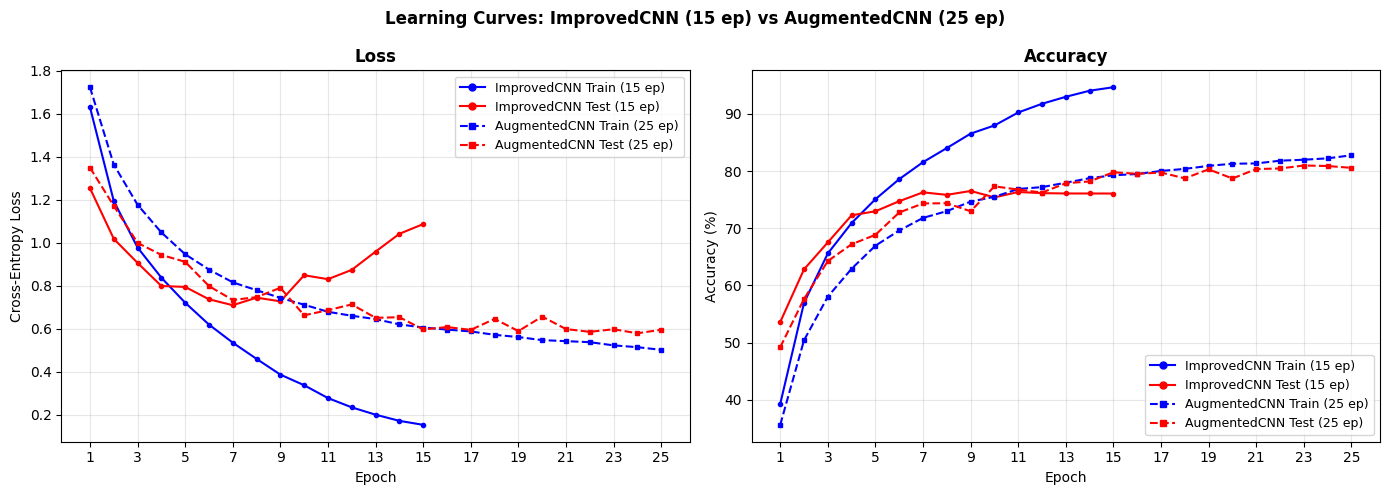

Saved: aug_learning_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# ── Cell AUG4: Learning curves ── ImprovedCNN vs AugmentedCNN ───────────────────
# Convention (matches all earlier plots in this notebook):
#   blue 'b' = Train  |  red 'r' = Test
#   solid '-' + circle 'o'  = ImprovedCNN (baseline, 15 epochs)
#   dashed '--' + square 's' = AugmentedCNN (25 epochs, reduced augmentation)
from matplotlib.lines import Line2D

epochs_imp = range(1, len(imp_train_losses) + 1)   # 15 epochs
epochs_aug = range(1, len(aug_train_losses) + 1)   # 25 epochs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: ImprovedCNN (15 ep) vs AugmentedCNN (25 ep)',
             fontsize=12, fontweight='bold')

ax1.plot(epochs_imp, imp_train_losses, 'b-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs_imp, imp_test_losses,  'r-o',  markersize=3, linewidth=1.5)
ax1.plot(epochs_aug, aug_train_losses, 'b--s', markersize=3, linewidth=1.5)
ax1.plot(epochs_aug, aug_test_losses,  'r--s', markersize=3, linewidth=1.5)
ax1.set_title('Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_xticks(range(1, len(epochs_aug) + 1, 2))
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_imp, imp_train_accs, 'b-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs_imp, imp_test_accs,  'r-o',  markersize=3, linewidth=1.5)
ax2.plot(epochs_aug, aug_train_accs, 'b--s', markersize=3, linewidth=1.5)
ax2.plot(epochs_aug, aug_test_accs,  'r--s', markersize=3, linewidth=1.5)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(range(1, len(epochs_aug) + 1, 2))
ax2.grid(True, alpha=0.3)

legend_elements = [
    Line2D([0],[0], color='b', linestyle='-',  marker='o', markersize=5, label='ImprovedCNN Train (15 ep)'),
    Line2D([0],[0], color='r', linestyle='-',  marker='o', markersize=5, label='ImprovedCNN Test (15 ep)'),
    Line2D([0],[0], color='b', linestyle='--', marker='s', markersize=5, label='AugmentedCNN Train (25 ep)'),
    Line2D([0],[0], color='r', linestyle='--', marker='s', markersize=5, label='AugmentedCNN Test (25 ep)'),
]
ax1.legend(handles=legend_elements, fontsize=9)
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('aug_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aug_learning_curves.png')
try:
    from google.colab import files; files.download('aug_learning_curves.png')
except ImportError:
    pass

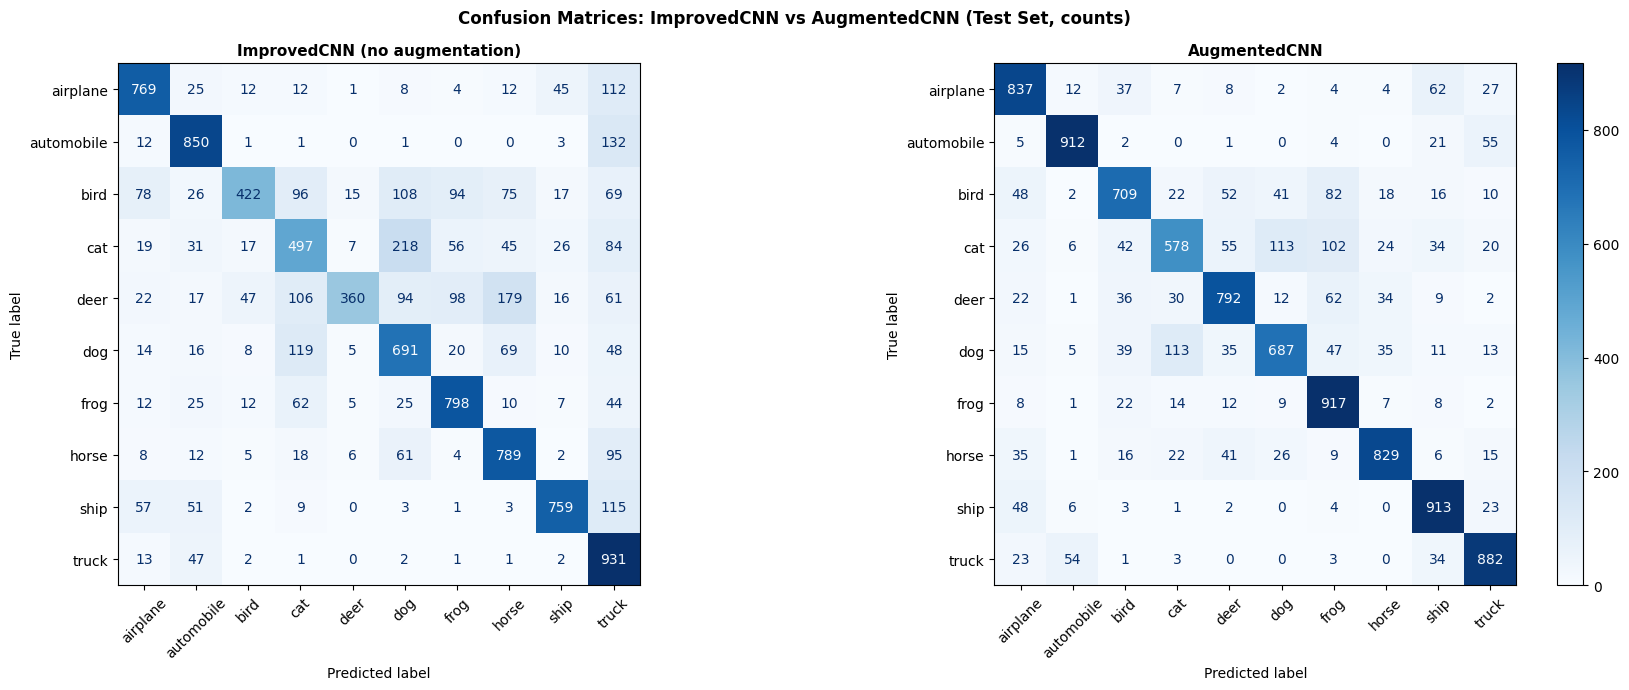

Saved: aug_confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# ── Cell AUG5: Confusion matrices — side by side ───────────────────────────────
y_true_base, y_pred_base, _ = get_predictions(improved_model, test_loader_norm)
y_true_aug,  y_pred_aug,  _ = get_predictions(aug_model, aug_test_loader)

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_aug  = confusion_matrix(y_true_aug,  y_pred_aug)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrices: ImprovedCNN vs AugmentedCNN (Test Set, counts)',
             fontsize=12, fontweight='bold')

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=classes)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[0].set_title('ImprovedCNN (no augmentation)', fontsize=11, fontweight='bold')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[1].set_title('AugmentedCNN', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('aug_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aug_confusion_matrices.png')
try:
    from google.colab import files; files.download('aug_confusion_matrices.png')
except ImportError:
    pass

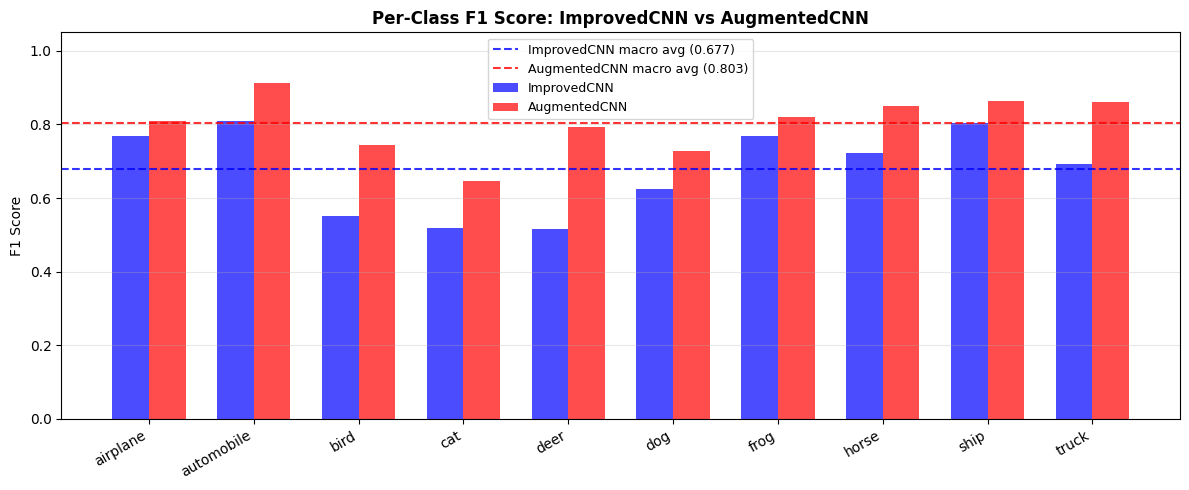

Saved: aug_f1_bars.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Metric                           ImprovedCNN    AugmentedCNN
Final Train Accuracy                  94.66%          82.76%
Final Test Accuracy                    76.07%          80.56%
Train/Test Gap                        18.59%           2.20%
Final Train Loss                      0.1528          0.5015
Final Test Loss                        1.0861          0.5949
Macro F1                               0.677           0.803
Macro AUC-ROC                          0.948           0.980

Per-class F1:
Class           ImprovedCNN AugmentedCNN        Δ
------------------------------------------------
airplane              0.767        0.810 +  0.042
automobile            0.810        0.912 +  0.102
bird                  0.552        0.744 +  0.191
cat                   0.517        0.646 +  0.128
deer                  0.515        0.793 +  0.278
dog                   0.625        0.727 +  0.102
frog                  0.769        0.821 +  0.052
horse                 0.723        0.850 +  0

In [43]:
# ── Cell AUG6: AUC-ROC + Per-class F1 bar chart + summary table ──────────────
# ── AUC-ROC ───────────────────────────────────────────────────────────────────
def get_probs(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for images, _ in loader:
            outputs = model(images.to(device))
            probs   = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_probs)

probs_base = get_probs(improved_model, test_loader_norm)
probs_aug  = get_probs(aug_model,      aug_test_loader)

auc_base = roc_auc_score(y_true_base, probs_base, multi_class='ovr', average='macro')
auc_aug  = roc_auc_score(y_true_aug,  probs_aug,  multi_class='ovr', average='macro')

# ── F1 ────────────────────────────────────────────────────────────────────────
f1_base      = f1_score(y_true_base, y_pred_base, average=None)
f1_aug       = f1_score(y_true_aug,  y_pred_aug,  average=None)
f1_macro_base = f1_score(y_true_base, y_pred_base, average='macro')
f1_macro_aug  = f1_score(y_true_aug,  y_pred_aug,  average='macro')

x, width = np.arange(10), 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, f1_base, width, label='ImprovedCNN',  color='b', alpha=0.7)
ax.bar(x + width/2, f1_aug,  width, label='AugmentedCNN', color='r', alpha=0.7)
ax.axhline(f1_macro_base, color='b', ls='--', lw=1.5, alpha=0.8,
           label=f'ImprovedCNN macro avg ({f1_macro_base:.3f})')
ax.axhline(f1_macro_aug,  color='r', ls='--', lw=1.5, alpha=0.8,
           label=f'AugmentedCNN macro avg ({f1_macro_aug:.3f})')
ax.set_title('Per-Class F1 Score: ImprovedCNN vs AugmentedCNN',
             fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('aug_f1_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: aug_f1_bars.png')
try:
    from google.colab import files; files.download('aug_f1_bars.png')
except ImportError:
    pass

# Summary table
print('\n' + '=' * 62)
print(f"{'Metric':<28} {'ImprovedCNN':>15} {'AugmentedCNN':>15}")
print('=' * 62)
print(f"{'Final Train Accuracy':<28} {imp_train_accs[-1]:>14.2f}% {aug_train_accs[-1]:>14.2f}%")
print(f"{'Final Test Accuracy':<28}  {imp_test_accs[-1]:>14.2f}% {aug_test_accs[-1]:>14.2f}%")
print(f"{'Train/Test Gap':<28} {imp_train_accs[-1]-imp_test_accs[-1]:>14.2f}% {aug_train_accs[-1]-aug_test_accs[-1]:>14.2f}%")
print(f"{'Final Train Loss':<28} {imp_train_losses[-1]:>15.4f} {aug_train_losses[-1]:>15.4f}")
print(f"{'Final Test Loss':<28}  {imp_test_losses[-1]:>15.4f} {aug_test_losses[-1]:>15.4f}")
print(f"{'Macro F1':<28} {f1_macro_base:>15.3f} {f1_macro_aug:>15.3f}")
print(f"{'Macro AUC-ROC':<28} {auc_base:>15.3f} {auc_aug:>15.3f}")
print('=' * 62)
print('\nPer-class F1:')
print(f"{'Class':<14} {'ImprovedCNN':>12} {'AugmentedCNN':>12} {'Δ':>8}")
print('-' * 48)
for cls, fb, fa in zip(classes, f1_base, f1_aug):
    delta = fa - fb
    print(f"{cls:<14} {fb:>12.3f} {fa:>12.3f} {'+' if delta>=0 else ''}{delta:>7.3f}")

PART 5 - NEW MODEL

In [44]:
# ── Cell P1: Imports ──────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('PatchMLP_CNN imports ready.')



PatchMLP_CNN imports ready.


In [45]:
# ── Cell P2: DataLoaders ──────────────────────────────────────────────────────
# Reuse existing train_loader / test_loader from ImprovedCNN section.
# If runtime was reset, uncomment the block below:

# CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
# CIFAR_STD  = (0.2470, 0.2434, 0.2615)
# norm_transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
# ])
# train_dataset_norm = datasets.CIFAR10('./data', train=True,  download=True,  transform=norm_transform)
# test_dataset_norm  = datasets.CIFAR10('./data', train=False, download=False, transform=norm_transform)
# train_loader = DataLoader(train_dataset_norm, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
# test_loader  = DataLoader(test_dataset_norm,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train loader: {len(train_loader.dataset):,} samples')
print(f'Test  loader: {len(test_loader.dataset):,} samples')


Train loader: 50,000 samples
Test  loader: 10,000 samples


In [46]:
# ── Cell P3: PatchMLP_CNN Model ───────────────────────────────────────────────
#
# Architecture
# ────────────
# Input image (3 × 32 × 32) is divided into 4 non-overlapping patches (2×2 grid).
# Each patch is 3 × 16 × 16 = 768 dimensions when flattened.
#
# MLP branch — 4 independent patch MLPs (no shared weights):
#   Each patch: Flatten(768) → FC(768→256) → BN → ReLU → Dropout(0.4)
#                            → FC(256→128) → BN → ReLU
#   Concat 4 patches: 4 × 128 = 512-dim MLP embedding
#
# CNN branch — identical to ImprovedCNN:
#   Conv1(3→32) → ReLU → MaxPool
#   Conv2(32→64)→ ReLU → MaxPool
#   Conv3(64→128)→ReLU → MaxPool
#   Conv4(128→256)→ReLU → MaxPool
#   Flatten → FC(1024→256) → ReLU → Dropout(0.5)
#   Output: 256-dim CNN embedding
#
# Fusion:
#   Concat([512, 256]) → 768-dim
#   FC(768→256) → BN → ReLU → Dropout(0.4)
#   FC(256→10)  → class logits
#
# Key hyperparameter differences from ImprovedCNN:
#   + Batch normalisation in MLP and fusion layers (ImprovedCNN has none)
#   + Dropout(0.4) in MLP/fusion vs Dropout(0.5) in CNN branch
#   + 4× parallel patch MLPs — each sees 1/4 of the image
#   + No handcrafted features — all learned end-to-end

PATCH_SIZE  = 16          # 16×16 pixels per patch
N_PATCHES   = 4           # 2×2 grid
PATCH_DIM   = 3 * PATCH_SIZE * PATCH_SIZE   # 768
MLP_HIDDEN  = 256
MLP_OUT     = 128
CNN_OUT     = 256
FUSE_HIDDEN = 256
N_CLASSES   = 10


class PatchMLP_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── 4 independent patch MLPs ─────────────────────────────────────────
        # Using nn.ModuleList so PyTorch registers all parameters
        self.patch_mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(PATCH_DIM, MLP_HIDDEN),
                nn.BatchNorm1d(MLP_HIDDEN),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(MLP_HIDDEN, MLP_OUT),
                nn.BatchNorm1d(MLP_OUT),
                nn.ReLU(),
            )
            for _ in range(N_PATCHES)
        ])

        # ── CNN branch (identical to ImprovedCNN) ────────────────────────────
        self.conv1   = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2   = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3   = nn.Conv2d(64,  128, 3, padding=1)
        self.conv4   = nn.Conv2d(128, 256, 3, padding=1)
        self.cnn_fc  = nn.Linear(256 * 2 * 2, CNN_OUT)
        self.cnn_drop = nn.Dropout(0.5)

        # ── Fusion classifier ────────────────────────────────────────────────
        fuse_in = N_PATCHES * MLP_OUT + CNN_OUT   # 512 + 256 = 768
        self.fuse_fc1  = nn.Linear(fuse_in, FUSE_HIDDEN)
        self.fuse_bn   = nn.BatchNorm1d(FUSE_HIDDEN)
        self.fuse_drop = nn.Dropout(0.4)
        self.fuse_fc2  = nn.Linear(FUSE_HIDDEN, N_CLASSES)

    def _extract_patches(self, x):
        """
        x : (B, 3, 32, 32)
        Returns list of 4 tensors, each (B, 768)
        Patches: top-left, top-right, bottom-left, bottom-right
        """
        p = PATCH_SIZE
        patches = [
            x[:, :, :p,  :p ].reshape(x.size(0), -1),   # top-left
            x[:, :, :p,  p: ].reshape(x.size(0), -1),   # top-right
            x[:, :,  p:, :p ].reshape(x.size(0), -1),   # bottom-left
            x[:, :,  p:,  p:].reshape(x.size(0), -1),   # bottom-right
        ]
        return patches

    def forward(self, x):
        # MLP branch
        patches = self._extract_patches(x)
        mlp_embs = [mlp(patch) for mlp, patch in zip(self.patch_mlps, patches)]
        mlp_emb = torch.cat(mlp_embs, dim=1)              # (B, 512)

        # CNN branch
        c = F.relu(self.conv1(x)); c = F.max_pool2d(c, 2)
        c = F.relu(self.conv2(c)); c = F.max_pool2d(c, 2)
        c = F.relu(self.conv3(c)); c = F.max_pool2d(c, 2)
        c = F.relu(self.conv4(c)); c = F.max_pool2d(c, 2)
        c = c.view(c.size(0), -1)
        c = F.relu(self.cnn_fc(c))
        cnn_emb = self.cnn_drop(c)                         # (B, 256)

        # Fusion
        fused = torch.cat([mlp_emb, cnn_emb], dim=1)      # (B, 768)
        fused = F.relu(self.fuse_bn(self.fuse_fc1(fused)))
        fused = self.fuse_drop(fused)
        return self.fuse_fc2(fused)                        # (B, 10)


patch_model     = PatchMLP_CNN().to(device)
patch_criterion = nn.CrossEntropyLoss()
patch_optimizer = optim.Adam(patch_model.parameters(), lr=0.001, weight_decay=1e-4)
# weight_decay adds L2 regularisation — not used in ImprovedCNN

total = sum(p.numel() for p in patch_model.parameters())
print(f'PatchMLP_CNN — {total:,} parameters')
print(patch_model)


PatchMLP_CNN — 1,772,874 parameters
PatchMLP_CNN(
  (patch_mlps): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.4, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
    )
  )
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (cnn_fc): Linear(in_features=1024, out_features=256, bias=True)
  (cnn_drop): Dropout(p=0.5, inplace=False)
  (fuse_fc1): Linear(in_features=768, out_features=256, bias=True)
  (fuse_b

In [47]:
# ── Cell P4: Train / Test Functions ──────────────────────────────────────────
def train_patch(model, loader):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        patch_optimizer.zero_grad()
        outputs = model(imgs)
        loss    = patch_criterion(outputs, labels)
        loss.backward()
        patch_optimizer.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total


def test_patch(model, loader):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = patch_criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()
    return running_loss / len(loader), 100 * correct / total



In [48]:

# ── Cell P5: Training Loop ────────────────────────────────────────────────────
NUM_EPOCHS = 15

patch_train_losses, patch_test_losses = [], []
patch_train_accs,   patch_test_accs   = [], []

print(f"{'Epoch':>5} {'Tr Loss':>9} {'Tr Acc':>8} {'Te Loss':>9} {'Te Acc':>8}")
print("-" * 45)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_patch(patch_model, train_loader)
    te_loss, te_acc = test_patch(patch_model,  test_loader)

    patch_train_losses.append(tr_loss)
    patch_test_losses.append(te_loss)
    patch_train_accs.append(tr_acc)
    patch_test_accs.append(te_acc)

    print(f"{epoch:>5} {tr_loss:>9.4f} {tr_acc:>7.2f}% {te_loss:>9.4f} {te_acc:>7.2f}%")

print("\nTraining complete.")


Epoch   Tr Loss   Tr Acc   Te Loss   Te Acc
---------------------------------------------
    1    1.4970   44.95%    1.2600   53.76%
    2    1.1343   59.15%    1.0619   61.46%
    3    0.9526   66.11%    0.9825   65.30%
    4    0.8133   71.37%    0.8076   71.58%
    5    0.7158   74.84%    0.7501   74.03%
    6    0.6346   78.18%    0.6995   76.02%
    7    0.5527   80.91%    0.7239   76.48%
    8    0.4975   82.89%    0.7301   75.79%
    9    0.4320   85.25%    0.7393   76.70%
   10    0.3895   86.56%    0.7144   77.88%
   11    0.3367   88.51%    0.7901   76.95%
   12    0.2972   89.92%    0.8223   76.55%
   13    0.2669   90.90%    0.8291   76.21%
   14    0.2371   92.03%    0.7825   77.53%
   15    0.2090   92.91%    0.8519   77.64%

Training complete.


In [49]:
# ── Cell P6: Final Metrics ────────────────────────────────────────────────────
imp_final_train = imp_train_accs[-1]
imp_final_test  = imp_test_accs[-1]
imp_gap         = imp_final_train - imp_final_test

# Patch model predictions
patch_model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = patch_model(imgs)
        probs   = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.append(preds.cpu())
        all_labels.append(labels)
        all_probs.append(probs.cpu())

p_preds  = torch.cat(all_preds).numpy()
p_labels = torch.cat(all_labels).numpy()
p_probs  = torch.cat(all_probs).numpy()

p_f1   = f1_score(p_labels, p_preds, average='macro')
p_auc  = roc_auc_score(label_binarize(p_labels, classes=list(range(10))),
                        p_probs, average='macro', multi_class='ovr')
p_gap  = patch_train_accs[-1] - patch_test_accs[-1]

classes = test_loader.dataset.classes

print("\n" + "=" * 66)
print(f"{'Metric':<32} {'ImprovedCNN':>14} {'PatchMLP_CNN':>14}")
print("=" * 66)
print(f"{'Final Train Accuracy':<32} {imp_final_train:>13.2f}% {patch_train_accs[-1]:>13.2f}%")
print(f"{'Final Test Accuracy':<32} {imp_final_test:>13.2f}% {patch_test_accs[-1]:>13.2f}%")
print(f"{'Train/Test Gap':<32} {imp_gap:>13.2f}% {p_gap:>13.2f}%")
print(f"{'Macro F1':<32} {'N/A':>14} {p_f1:>14.3f}")
print(f"{'Macro AUC-ROC':<32} {'N/A':>14} {p_auc:>14.3f}")
print("=" * 66)

per_class_f1 = f1_score(p_labels, p_preds, average=None)
# ImprovedCNN per-class F1 from report
imp_per_class = [0.743, 0.819, 0.576, 0.529, 0.523,
                 0.606, 0.768, 0.742, 0.812, 0.675]
print(f"\n{'Class':<14} {'ImprovedCNN':>12} {'PatchMLP_CNN':>13} {'Delta':>8}")
print("-" * 52)
for i, cls in enumerate(classes):
    d = per_class_f1[i] - imp_per_class[i]
    sign = "+" if d >= 0 else ""
    print(f"{cls:<14} {imp_per_class[i]:>12.3f} {per_class_f1[i]:>13.3f} {sign}{d:>7.3f}")



Metric                              ImprovedCNN   PatchMLP_CNN
Final Train Accuracy                     94.66%         92.91%
Final Test Accuracy                      76.07%         77.64%
Train/Test Gap                           18.59%         15.27%
Macro F1                                    N/A          0.776
Macro AUC-ROC                               N/A          0.970

Class           ImprovedCNN  PatchMLP_CNN    Delta
----------------------------------------------------
airplane              0.743         0.802 +  0.059
automobile            0.819         0.879 +  0.060
bird                  0.576         0.693 +  0.117
cat                   0.529         0.588 +  0.059
deer                  0.523         0.727 +  0.204
dog                   0.606         0.682 +  0.076
frog                  0.768         0.842 +  0.074
horse                 0.742         0.820 +  0.078
ship                  0.812         0.862 +  0.050
truck                 0.675         0.863 +  0.188


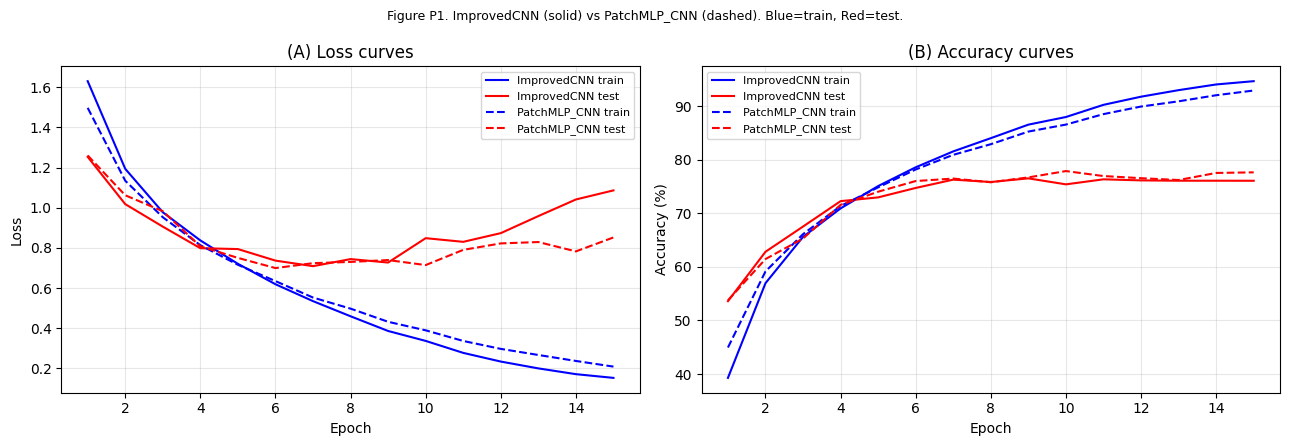

Saved: patch_learning_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:

# ── Cell P7: Learning Curves ──────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs, imp_train_losses,   'b-',  label='ImprovedCNN train')
axes[0].plot(epochs, imp_test_losses,    'r-',  label='ImprovedCNN test')
axes[0].plot(epochs, patch_train_losses, 'b--', label='PatchMLP_CNN train')
axes[0].plot(epochs, patch_test_losses,  'r--', label='PatchMLP_CNN test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('(A) Loss curves'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, imp_train_accs,   'b-',  label='ImprovedCNN train')
axes[1].plot(epochs, imp_test_accs,    'r-',  label='ImprovedCNN test')
axes[1].plot(epochs, patch_train_accs, 'b--', label='PatchMLP_CNN train')
axes[1].plot(epochs, patch_test_accs,  'r--', label='PatchMLP_CNN test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('(B) Accuracy curves'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure P1. ImprovedCNN (solid) vs PatchMLP_CNN (dashed). Blue=train, Red=test.',
             fontsize=9)
plt.tight_layout()
plt.savefig('patch_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: patch_learning_curves.png")
try:
    from google.colab import files; files.download('patch_learning_curves.png')
except ImportError:
    pass



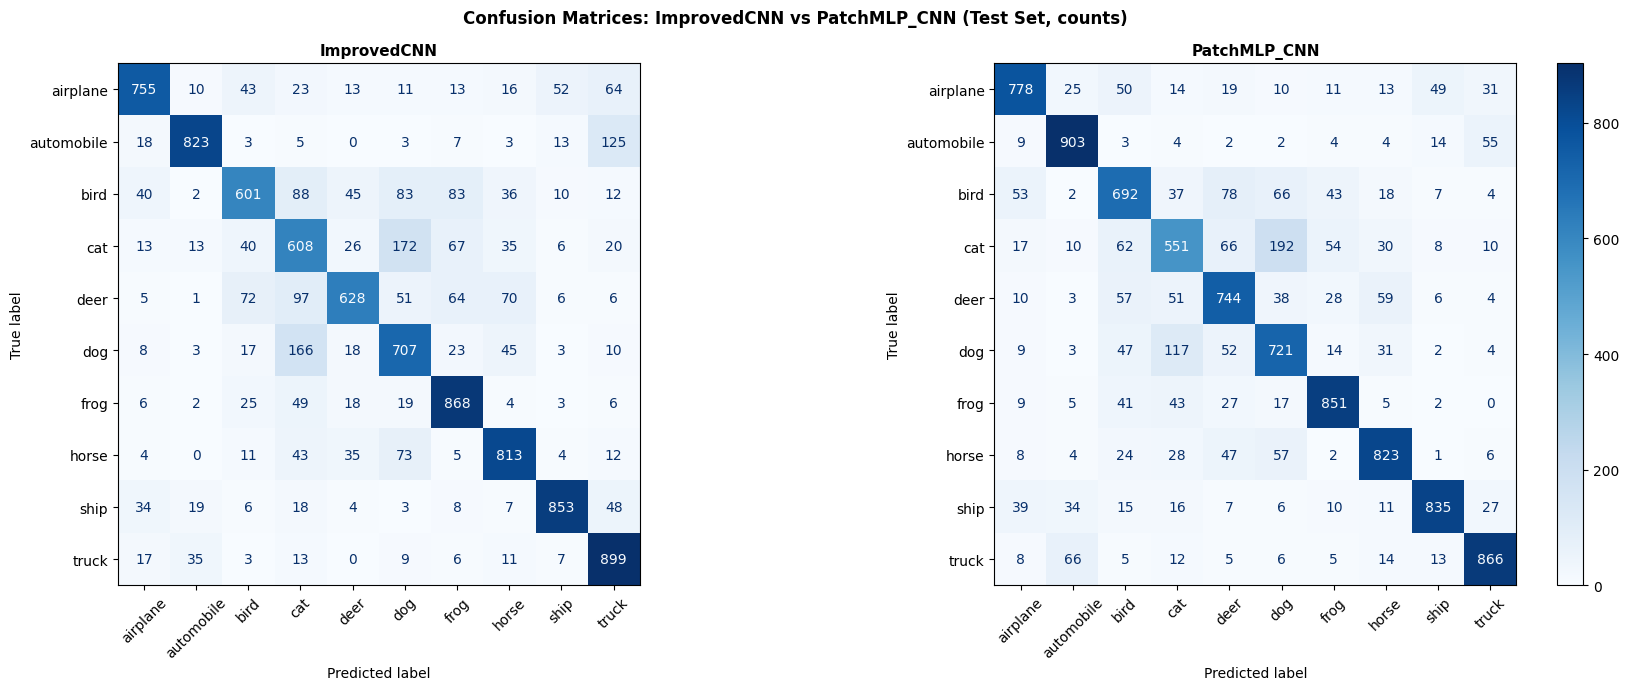

Saved: patch_confusion_matrices.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
# ── Cell P8: Confusion Matrices ───────────────────────────────────────────────
# ImprovedCNN predictions
improved_model.eval()
imp_all_preds, imp_all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = improved_model(imgs)
        _, preds = outputs.max(1)
        imp_all_preds.append(preds.cpu())
        imp_all_labels.append(labels)
imp_preds_arr  = torch.cat(imp_all_preds).numpy()
imp_labels_arr = torch.cat(imp_all_labels).numpy()

cm_imp   = confusion_matrix(imp_labels_arr, imp_preds_arr)
cm_patch = confusion_matrix(p_labels, p_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrices: ImprovedCNN vs PatchMLP_CNN (Test Set, counts)',
             fontsize=12, fontweight='bold')

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_imp, display_labels=classes)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[0].set_title('ImprovedCNN', fontsize=11, fontweight='bold')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_patch, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[1].set_title('PatchMLP_CNN', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('patch_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: patch_confusion_matrices.png")
try:
    from google.colab import files; files.download('patch_confusion_matrices.png')
except ImportError:
    pass


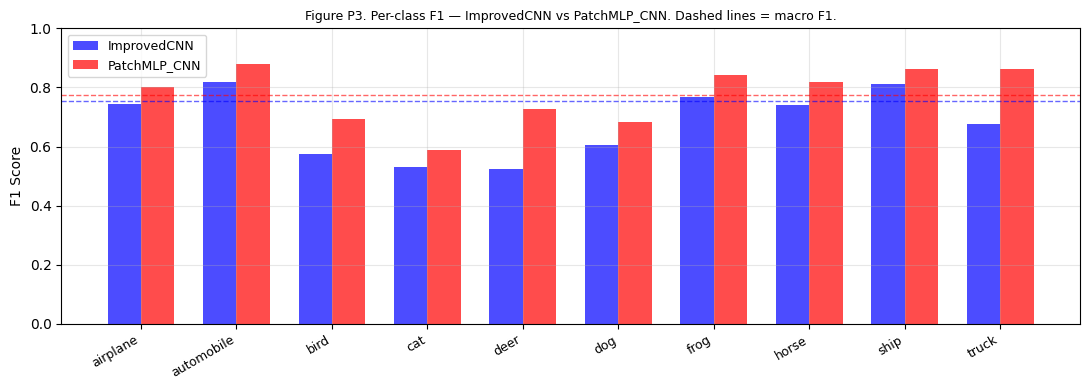

Saved: patch_f1_bars.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:

# ── Cell P9: Per-Class F1 Bar Chart ──────────────────────────────────────────
x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, imp_per_class, width, label='ImprovedCNN',   color='b', alpha=0.7)
ax.bar(x + width/2, per_class_f1,  width, label='PatchMLP_CNN',  color='r', alpha=0.7)

# Macro F1 lines — load ImprovedCNN macro F1 if available, else use report value
imp_macro_f1 = 0.753
ax.axhline(imp_macro_f1, color='b', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(p_f1,         color='r', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xticks(x); ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1)
ax.set_title('Figure P3. Per-class F1 — ImprovedCNN vs PatchMLP_CNN. Dashed lines = macro F1.',
             fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('patch_f1_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: patch_f1_bars.png")
try:
    from google.colab import files; files.download('patch_f1_bars.png')
except ImportError:
    pass

In [53]:
# ── Run this as the very last cell ───────────────────────────────────────────
import zipfile
import os

# List all files you want to download
files_to_zip = [
    'results_initial_cnn.json',
    'results_improved_cnn.json',
    'results_mlp.json',
    'weights_initial_cnn.pth',
    'weights_improved_cnn.pth',
    'weights_mlp.pth',
    'learning_curves.png',
    'comparison_learning_curves.png',
    'gradient_magnitudes.png',
    'improved_gradient_magnitudes.png',
    'combined_gradient_magnitudes.png',
    'key_layers_gradient_comparison.png',
    'mlp_vs_cnn_curves.png',
    'cnn_conv1_filters.png',
    'mlp_fc1_weights.png',
    'confusion_matrix_initial.png',
    'confusion_matrix_comparison.png',
    'confusion_matrix_cnn_vs_mlp.png',
    'cifar10_samples.png',
    'overfitting_solutions.png',
    'augmentation_visualisation.png',
    'aug_learning_curves.png',
    'aug_confusion_matrices.png',
    'aug_f1_bars.png',
    'patch_learning_curves.png',
    'patch_confusion_matrices.png',
    'patch_f1_bars.png',
    'initial_gradient_magnitudes.png',
    'confusion_matrix_initial.png',
]

with zipfile.ZipFile('all_results.zip', 'w') as zf:
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f)
            print(f'Added: {f}')
        else:
            print(f'Missing: {f}')

# Download the zip
from google.colab import files
files.download('all_results.zip')
print('Download started.')

Added: results_initial_cnn.json
Missing: results_improved_cnn.json
Missing: results_mlp.json
Added: weights_initial_cnn.pth
Missing: weights_improved_cnn.pth
Missing: weights_mlp.pth
Added: learning_curves.png
Added: comparison_learning_curves.png
Added: gradient_magnitudes.png
Missing: improved_gradient_magnitudes.png
Added: combined_gradient_magnitudes.png
Added: key_layers_gradient_comparison.png
Added: mlp_vs_cnn_curves.png
Added: cnn_conv1_filters.png
Added: mlp_fc1_weights.png
Added: confusion_matrix_initial.png
Added: confusion_matrix_comparison.png
Added: confusion_matrix_cnn_vs_mlp.png
Added: cifar10_samples.png
Added: overfitting_solutions.png
Missing: augmentation_visualisation.png
Added: aug_learning_curves.png
Added: aug_confusion_matrices.png
Added: aug_f1_bars.png
Added: patch_learning_curves.png
Added: patch_confusion_matrices.png
Added: patch_f1_bars.png
Added: initial_gradient_magnitudes.png
Added: confusion_matrix_initial.png


/usr/lib/python3.12/zipfile/__init__.py:1624: UserWarning: Duplicate name: 'confusion_matrix_initial.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
